<a href="https://www.kaggle.com/code/subbhaa/group04-bloodmnist-medmnist-cse475-task1-eda?scriptVersionId=336714185" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# BloodMNIST Task 1: Exploratory Data Analysis (EDA)

## Course Information

- **Course:** CSE475 – Machine Learning
- **Project Track:** Track 2 – Image-to-Graph using Graph Convolutional Network (GCN)
- **Framework:** PyTorch
- **Platform:** Kaggle
- **Dataset:** BloodMNIST (MedMNIST v2)

---

## Proposed Final Architecture

BloodMNIST Image

↓

CNN Feature Extractor

↓

Attention Module

↓

7×7 Feature Map

↓

Image-to-Graph Conversion (49 Spatial Nodes)

↓

Graph Convolutional Network (GCN)

↓

Global Pooling

↓

8-Class Blood Cell Classification

---

## Objective

The objective of this notebook is to perform a comprehensive Exploratory Data Analysis (EDA) of the BloodMNIST dataset before developing the proposed CNN–Attention–GCN model.

This analysis investigates the dataset structure, image statistics, class distribution, image quality, duplicate samples, potential data leakage, and graph readiness. The observations obtained from this notebook will be used to justify the design choices of the proposed graph-based deep learning architecture in the subsequent project tasks.

---

## Scope of Task 1

This notebook includes:

- Dataset loading and integrity verification
- Dataset summary
- Class distribution analysis
- Sample image visualization
- Image resolution analysis
- Pixel and RGB statistics
- Image quality analysis
- Duplicate detection
- Data leakage inspection
- Split comparison
- PCA visualization
- Graph-readiness analysis
- Patch-level analysis
- Key findings
- Related work
- Research gap
- Task 1 conclusion

---

## Excluded from Task 1

The following tasks are intentionally **NOT** performed in this notebook:

- CNN training
- Attention module training
- GCN training
- Hyperparameter tuning
- Data augmentation
- Model evaluation
- Performance comparison

These experiments will be conducted in **Task 2** and **Task 3** according to the project requirements.

# 1. Import Required Libraries and Configure Reproducibility

This section imports all required Python libraries used throughout the Exploratory Data Analysis (EDA). It also fixes the random seed to ensure reproducible results, configures pandas display options for better readability, suppresses unnecessary warnings, and creates directories for saving generated figures and tables.

Reproducibility is essential for scientific research because it ensures that the same analysis produces identical results every time it is executed.

In [1]:
# ============================================================
# 1. Imports and Reproducibility
# ============================================================

from pathlib import Path
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Suppress unnecessary warnings
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# ------------------------------------------------------------
# Pandas display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------
OUTPUT_DIR = Path("task1_eda_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Environment Information
# ------------------------------------------------------------
print("=" * 60)
print("BloodMNIST Task 1 - EDA Environment")
print("=" * 60)
print(f"Random Seed      : {RANDOM_STATE}")
print(f"NumPy Version    : {np.__version__}")
print(f"Pandas Version   : {pd.__version__}")
print(f"Output Directory : {OUTPUT_DIR.resolve()}")
print("=" * 60)

BloodMNIST Task 1 - EDA Environment
Random Seed      : 42
NumPy Version    : 2.0.2
Pandas Version   : 2.3.3
Output Directory : /kaggle/working/task1_eda_outputs


# 2. Load the BloodMNIST Dataset

This section automatically locates and loads the **BloodMNIST MedMNIST Dataset** from the Kaggle environment.

The notebook searches several common locations before loading the dataset.

After loading, the six official arrays are extracted:

- train_images
- train_labels
- val_images
- val_labels
- test_images
- test_labels

This step only loads the dataset. No preprocessing or model training is performed.

# 2. Load the BloodMNIST Dataset

In this section, the official BloodMNIST dataset is loaded from the attached Kaggle dataset.

The dataset is stored in a compressed NumPy (.npz) file containing the official train, validation, and test splits provided by MedMNIST. These official splits are preserved throughout the project to ensure fair benchmarking and to prevent data leakage.

The loaded arrays will be used in all subsequent EDA analyses.

In [2]:
# ============================================================
# 2. Load BloodMNIST Dataset
# ============================================================

from pathlib import Path
import numpy as np

# Kaggle dataset path
DATA_PATH = Path(
    "/kaggle/input/datasets/subbhaa/bloodmnist-medmnist-dataset/bloodmnist.npz"
)

# Verify dataset exists
assert DATA_PATH.exists(), f"Dataset not found:\n{DATA_PATH}"

print(f"Dataset Path : {DATA_PATH}")

# Load NPZ file
with np.load(DATA_PATH) as data:

    print("\nAvailable Keys:")
    print(data.files)

    train_images = data["train_images"]
    train_labels = data["train_labels"].reshape(-1)

    val_images = data["val_images"]
    val_labels = data["val_labels"].reshape(-1)

    test_images = data["test_images"]
    test_labels = data["test_labels"].reshape(-1)

print("\nBloodMNIST dataset loaded successfully.")

print("\nDataset Shapes")
print("-" * 35)
print(f"Train Images      : {train_images.shape}")
print(f"Train Labels      : {train_labels.shape}")

print(f"Validation Images : {val_images.shape}")
print(f"Validation Labels : {val_labels.shape}")

print(f"Test Images       : {test_images.shape}")
print(f"Test Labels       : {test_labels.shape}")

Dataset Path : /kaggle/input/datasets/subbhaa/bloodmnist-medmnist-dataset/bloodmnist.npz

Available Keys:
['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']

BloodMNIST dataset loaded successfully.

Dataset Shapes
-----------------------------------
Train Images      : (11959, 28, 28, 3)
Train Labels      : (11959,)
Validation Images : (1712, 28, 28, 3)
Validation Labels : (1712,)
Test Images       : (3421, 28, 28, 3)
Test Labels       : (3421,)


# 3. Label Mapping and Dataset Integrity Validation

## Purpose

Before performing any analysis, it is important to verify that the BloodMNIST dataset has been loaded correctly and contains no structural errors.

This section performs a comprehensive integrity check by validating:

- Official label mapping
- Number of images and labels
- Image dimensions
- RGB channels
- Pixel value range
- Image and label data types
- Missing (NaN) values
- Infinite values
- Valid class labels
- Zero-variance (blank) images

Ensuring dataset integrity helps prevent hidden errors that could affect later analysis and model development.

In [3]:
# ============================================================
# 3. Label Mapping and Comprehensive Dataset Integrity Validation
# ============================================================

LABEL_MAP = {
    0: "Basophil",
    1: "Eosinophil",
    2: "Erythroblast",
    3: "Immature Granulocytes",
    4: "Lymphocyte",
    5: "Monocyte",
    6: "Neutrophil",
    7: "Platelet",
}

SPLITS = {
    "Train": (train_images, train_labels),
    "Validation": (val_images, val_labels),
    "Test": (test_images, test_labels),
}

EXPECTED_KEYS = {
    "train_images",
    "train_labels",
    "val_images",
    "val_labels",
    "test_images",
    "test_labels",
}

print("=" * 70)
print("Dataset Integrity Validation")
print("=" * 70)

validation_records = []

for split_name, (images, labels) in SPLITS.items():

    record = {
        "Split": split_name,

        "Images": len(images),
        "Labels": len(labels),

        "Counts Match": len(images) == len(labels),

        "Image Shape": str(images.shape),

        "Image Rank": images.ndim,

        "Resolution": f"{images.shape[1]}×{images.shape[2]}",

        "Channels": images.shape[-1],

        "Image dtype": str(images.dtype),

        "Label dtype": str(labels.dtype),

        "Pixel Min": int(images.min()),

        "Pixel Max": int(images.max()),

        "Pixel Range Valid": (
            images.min() >= 0 and images.max() <= 255
        ),

        "NaN Pixels": int(np.isnan(images).sum()),

        "NaN Labels": int(np.isnan(labels).sum()),

        "Infinite Pixels": int(np.isinf(images).sum()),

        "Infinite Labels": int(np.isinf(labels).sum()),

        "Valid Labels": set(np.unique(labels)).issubset(set(LABEL_MAP.keys())),

        "Zero Variance Images": int(
            (images.reshape(len(images), -1).std(axis=1) == 0).sum()
        ),
    }

    validation_records.append(record)

validation_df = pd.DataFrame(validation_records)

display(validation_df)

# ----------------------------------------------------------
# Verify NPZ keys
# ----------------------------------------------------------

with np.load(DATA_PATH) as npz:
    loaded_keys = set(npz.files)

print("NPZ Keys Found:")
print(sorted(loaded_keys))

assert loaded_keys == EXPECTED_KEYS, "Unexpected NPZ file structure."

# ----------------------------------------------------------
# Critical Assertions
# ----------------------------------------------------------

assert validation_df["Counts Match"].all()
assert (validation_df["Image Rank"] == 4).all()
assert (validation_df["Channels"] == 3).all()
assert validation_df["Pixel Range Valid"].all()
assert (validation_df["NaN Pixels"] == 0).all()
assert (validation_df["NaN Labels"] == 0).all()
assert (validation_df["Infinite Pixels"] == 0).all()
assert (validation_df["Infinite Labels"] == 0).all()
assert validation_df["Valid Labels"].all()

print("\nAll integrity checks passed successfully.")

# Save report

validation_df.to_csv(
    TABLE_DIR / "dataset_integrity_validation.csv",
    index=False,
)

Dataset Integrity Validation


,Split,Images,Labels,Counts Match,Image Shape,Image Rank,Resolution,Channels,Image dtype,Label dtype,Pixel Min,Pixel Max,Pixel Range Valid,NaN Pixels,NaN Labels,Infinite Pixels,Infinite Labels,Valid Labels,Zero Variance Images
0,Train,11959,11959,True,"(11959, 28, 28, 3)",4,28×28,3,uint8,uint8,0,255,True,0,0,0,0,True,0
1,Validation,1712,1712,True,"(1712, 28, 28, 3)",4,28×28,3,uint8,uint8,0,255,True,0,0,0,0,True,0
2,Test,3421,3421,True,"(3421, 28, 28, 3)",4,28×28,3,uint8,uint8,0,255,True,0,0,0,0,True,0


NPZ Keys Found:
['test_images', 'test_labels', 'train_images', 'train_labels', 'val_images', 'val_labels']

All integrity checks passed successfully.


### Interpretation

The integrity validation confirms that the official BloodMNIST dataset was loaded successfully.

- All three official splits (Train, Validation, and Test) contain matching numbers of images and labels.
- Every image has the expected resolution of **28 × 28 pixels** with **3 RGB channels**.
- Pixel values are within the valid **0–255** range.
- No missing values (NaN) or infinite values were detected.
- All labels belong to the expected eight BloodMNIST classes (0–7).
- No zero-variance (blank) images were found.

These results indicate that the dataset is complete, internally consistent, and suitable for Exploratory Data Analysis (EDA) and subsequent model development.

# 4. Dataset Summary

###  Purpose

This section summarizes the overall characteristics of the BloodMNIST dataset.

The summary includes:

- Number of images in each official split
- Train / Validation / Test ratio
- Image resolution
- Number of channels
- Data types
- Pixel value range
- Number of classes
- Memory usage

A concise dataset summary provides a quick overview before proceeding to more detailed exploratory analyses.

In [4]:
# ============================================================
# 4. Dataset Summary
# ============================================================

summary_records = []

total_images = 0
total_image_memory = 0
total_label_memory = 0

for split_name, (images, labels) in SPLITS.items():

    image_count = len(images)

    total_images += image_count
    total_image_memory += images.nbytes
    total_label_memory += labels.nbytes

    summary_records.append({

        "Split": split_name,

        "Images": image_count,

        "Percentage (%)": round(
            image_count /
            (len(train_images)+len(val_images)+len(test_images))
            *100,
            2,
        ),

        "Height": images.shape[1],

        "Width": images.shape[2],

        "Channels": images.shape[3],

        "Image dtype": str(images.dtype),

        "Label dtype": str(labels.dtype),

        "Pixel Range": f"{int(images.min())} - {int(images.max())}",

        "Classes": len(np.unique(labels)),

        "Image Memory (MB)": round(images.nbytes / (1024**2), 2),

        "Label Memory (KB)": round(labels.nbytes / 1024, 2),

    })

dataset_summary_df = pd.DataFrame(summary_records)

# ------------------------------------------------------------
# Overall Dataset Summary
# ------------------------------------------------------------

total_row = pd.DataFrame([{

    "Split": "Total",

    "Images": total_images,

    "Percentage (%)": 100.00,

    "Height": train_images.shape[1],

    "Width": train_images.shape[2],

    "Channels": train_images.shape[3],

    "Image dtype": str(train_images.dtype),

    "Label dtype": str(train_labels.dtype),

    "Pixel Range": f"{int(train_images.min())} - {int(train_images.max())}",

    "Classes": len(LABEL_MAP),

    "Image Memory (MB)": round(total_image_memory/(1024**2),2),

    "Label Memory (KB)": round(total_label_memory/1024,2),

}])

dataset_summary_df = pd.concat(
    [dataset_summary_df, total_row],
    ignore_index=True,
)

display(dataset_summary_df)

# ------------------------------------------------------------
# Label Mapping Table
# ------------------------------------------------------------

label_mapping_df = pd.DataFrame({

    "Label ID": LABEL_MAP.keys(),

    "Blood Cell Class": LABEL_MAP.values()

})

display(label_mapping_df)

# ------------------------------------------------------------
# Save Tables
# ------------------------------------------------------------

dataset_summary_df.to_csv(
    TABLE_DIR / "dataset_summary.csv",
    index=False,
)

label_mapping_df.to_csv(
    TABLE_DIR / "label_mapping.csv",
    index=False,
)

print("="*70)
print("Dataset Summary")
print("="*70)

print(f"Total Images      : {total_images:,}")
print(f"Training Images   : {len(train_images):,}")
print(f"Validation Images : {len(val_images):,}")
print(f"Testing Images    : {len(test_images):,}")
print(f"Image Resolution  : {train_images.shape[1]} × {train_images.shape[2]}")
print(f"Channels          : {train_images.shape[3]} (RGB)")
print(f"Classes           : {len(LABEL_MAP)}")
print(f"Pixel Range       : {train_images.min()} - {train_images.max()}")
print(f"Image Memory      : {total_image_memory/(1024**2):.2f} MB")

,Split,Images,Percentage (%),Height,Width,Channels,Image dtype,Label dtype,Pixel Range,Classes,Image Memory (MB),Label Memory (KB)
0,Train,11959,69.97,28,28,3,uint8,uint8,0 - 255,8,26.82,11.68
1,Validation,1712,10.02,28,28,3,uint8,uint8,0 - 255,8,3.84,1.67
2,Test,3421,20.02,28,28,3,uint8,uint8,0 - 255,8,7.67,3.34
3,Total,17092,100.00,28,28,3,uint8,uint8,0 - 255,8,38.34,16.69


,Label ID,Blood Cell Class
0,0,Basophil
1,1,Eosinophil
2,2,Erythroblast
3,3,Immature Granulocytes
4,4,Lymphocyte
5,5,Monocyte
6,6,Neutrophil
7,7,Platelet


Dataset Summary
Total Images      : 17,092
Training Images   : 11,959
Validation Images : 1,712
Testing Images    : 3,421
Image Resolution  : 28 × 28
Channels          : 3 (RGB)
Classes           : 8
Pixel Range       : 0 - 255
Image Memory      : 38.34 MB


### Interpretation

The BloodMNIST dataset contains **17,092 RGB images** divided into the official **training, validation, and test** splits.

All images have a fixed spatial resolution of **28 × 28 pixels** with **three RGB channels**, making the dataset suitable for deep learning models without requiring image resizing.

The dataset contains **eight blood-cell classes**, and pixel intensities are stored as **uint8** values ranging from **0 to 255**.

The official split proportions are preserved throughout the project to ensure fair comparison with previous MedMNIST benchmark studies.

# 5. Class Distribution Analysis

## Purpose

Understanding the class distribution is an important step before training a machine learning model.

This section examines:

- Number of images in each class
- Class percentages
- Distribution across the official dataset splits
- Majority and minority classes
- Class imbalance ratio

Class imbalance is particularly important because highly imbalanced datasets may bias a classifier toward the majority classes. Therefore, evaluation metrics such as **Macro-F1 Score** and **Per-Class Recall** should accompany overall accuracy during model evaluation.

In [5]:
# ============================================================
# 5. Class Distribution Analysis
# ============================================================

class_records = []

for split_name, (_, labels) in SPLITS.items():

    split_total = len(labels)

    for label_id, class_name in LABEL_MAP.items():

        count = int(np.sum(labels == label_id))

        class_records.append({

            "Split": split_name,

            "Label ID": label_id,

            "Class": class_name,

            "Count": count,

            "Percentage": round(
                count / split_total * 100,
                2,
            ),
        })

class_distribution_df = pd.DataFrame(class_records)

# ----------------------------------------------------------
# Count Table
# ----------------------------------------------------------

count_table = class_distribution_df.pivot(
    index=["Label ID", "Class"],
    columns="Split",
    values="Count",
).reset_index()

# ----------------------------------------------------------
# Percentage Table
# ----------------------------------------------------------

percentage_table = class_distribution_df.pivot(
    index=["Label ID", "Class"],
    columns="Split",
    values="Percentage",
).reset_index()

# ----------------------------------------------------------
# Overall Distribution
# ----------------------------------------------------------

all_labels = np.concatenate([
    train_labels,
    val_labels,
    test_labels,
])

overall_counts = (
    pd.Series(all_labels)
    .value_counts()
    .sort_index()
)

overall_distribution_df = pd.DataFrame({

    "Label ID": list(LABEL_MAP.keys()),

    "Class": list(LABEL_MAP.values()),

    "Total Images": [
        int(overall_counts.get(i,0))
        for i in LABEL_MAP
    ]

})

overall_distribution_df["Percentage"] = round(
    overall_distribution_df["Total Images"]
    /
    overall_distribution_df["Total Images"].sum()
    *100,
    2,
)

overall_distribution_df["Cumulative %"] = (
    overall_distribution_df["Percentage"]
    .cumsum()
    .round(2)
)

# ----------------------------------------------------------
# Majority / Minority
# ----------------------------------------------------------

majority_row = overall_distribution_df.loc[
    overall_distribution_df["Total Images"].idxmax()
]

minority_row = overall_distribution_df.loc[
    overall_distribution_df["Total Images"].idxmin()
]

majority_class = majority_row["Class"]
minority_class = minority_row["Class"]

majority_count = int(majority_row["Total Images"])
minority_count = int(minority_row["Total Images"])

imbalance_ratio = round(
    majority_count/minority_count,
    2,
)

# ----------------------------------------------------------
# Dataset Balance Verdict
# ----------------------------------------------------------

if imbalance_ratio < 1.5:
    balance_status = "Well Balanced"

elif imbalance_ratio < 3:
    balance_status = "Moderately Imbalanced"

else:
    balance_status = "Highly Imbalanced"

# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

print("="*70)
print("Class Counts")
print("="*70)

display(count_table)

print("="*70)
print("Class Percentages")
print("="*70)

display(percentage_table)

print("="*70)
print("Overall Distribution")
print("="*70)

display(overall_distribution_df)

print("="*70)
print("Class Imbalance Summary")
print("="*70)

summary_df = pd.DataFrame({

    "Metric":[

        "Majority Class",

        "Minority Class",

        "Majority Images",

        "Minority Images",

        "Imbalance Ratio",

        "Dataset Status"

    ],

    "Value":[

        majority_class,

        minority_class,

        majority_count,

        minority_count,

        f"{imbalance_ratio}:1",

        balance_status

    ]

})

display(summary_df)

# ----------------------------------------------------------
# Save Tables
# ----------------------------------------------------------

count_table.to_csv(
    TABLE_DIR/"class_count_table.csv",
    index=False,
)

percentage_table.to_csv(
    TABLE_DIR/"class_percentage_table.csv",
    index=False,
)

overall_distribution_df.to_csv(
    TABLE_DIR/"overall_class_distribution.csv",
    index=False,
)

summary_df.to_csv(
    TABLE_DIR/"class_imbalance_summary.csv",
    index=False,
)

Class Counts


Split,Label ID,Class,Test,Train,Validation
0,0,Basophil,244,852,122
1,1,Eosinophil,624,2181,312
2,2,Erythroblast,311,1085,155
3,3,Immature Granulocytes,579,2026,290
4,4,Lymphocyte,243,849,122
5,5,Monocyte,284,993,143
6,6,Neutrophil,666,2330,333
7,7,Platelet,470,1643,235


Class Percentages


Split,Label ID,Class,Test,Train,Validation
0,0,Basophil,7.13,7.12,7.13
1,1,Eosinophil,18.24,18.24,18.22
2,2,Erythroblast,9.09,9.07,9.05
3,3,Immature Granulocytes,16.92,16.94,16.94
4,4,Lymphocyte,7.10,7.10,7.13
5,5,Monocyte,8.30,8.30,8.35
6,6,Neutrophil,19.47,19.48,19.45
7,7,Platelet,13.74,13.74,13.73


Overall Distribution


,Label ID,Class,Total Images,Percentage,Cumulative %
0,0,Basophil,1218,7.13,7.13
1,1,Eosinophil,3117,18.24,25.37
2,2,Erythroblast,1551,9.07,34.44
3,3,Immature Granulocytes,2895,16.94,51.38
4,4,Lymphocyte,1214,7.10,58.48
5,5,Monocyte,1420,8.31,66.79
6,6,Neutrophil,3329,19.48,86.27
7,7,Platelet,2348,13.74,100.01


Class Imbalance Summary


,Metric,Value
0,Majority Class,Neutrophil
1,Minority Class,Lymphocyte
2,Majority Images,3329
3,Minority Images,1214
4,Imbalance Ratio,2.74:1
5,Dataset Status,Moderately Imbalanced


### Interpretation

The BloodMNIST dataset contains eight blood-cell classes distributed across the official training, validation, and test splits.

The class distribution is not perfectly uniform. The largest class (majority class) contains more images than the smallest class (minority class), resulting in a measurable class imbalance.

Although the imbalance is not extreme, relying solely on classification accuracy could produce misleading conclusions. Therefore, future model evaluation should also report **Macro-F1 Score**, **Per-Class Recall**, and **Balanced Accuracy** to ensure that all blood-cell classes are evaluated fairly.

# 6. Class Distribution Visualization

This section visualizes the distribution of BloodMNIST classes across the official dataset splits.

The objectives are to:

- Visualize class frequencies in the training set.
- Compare class distributions across Train, Validation, and Test splits.
- Compare percentage distributions across splits.
- Verify whether the official dataset maintains a balanced split.
- Provide visual evidence supporting the class imbalance analysis presented in the previous section.

These visualizations help identify majority and minority classes and assess whether the data distribution is consistent across the official splits.

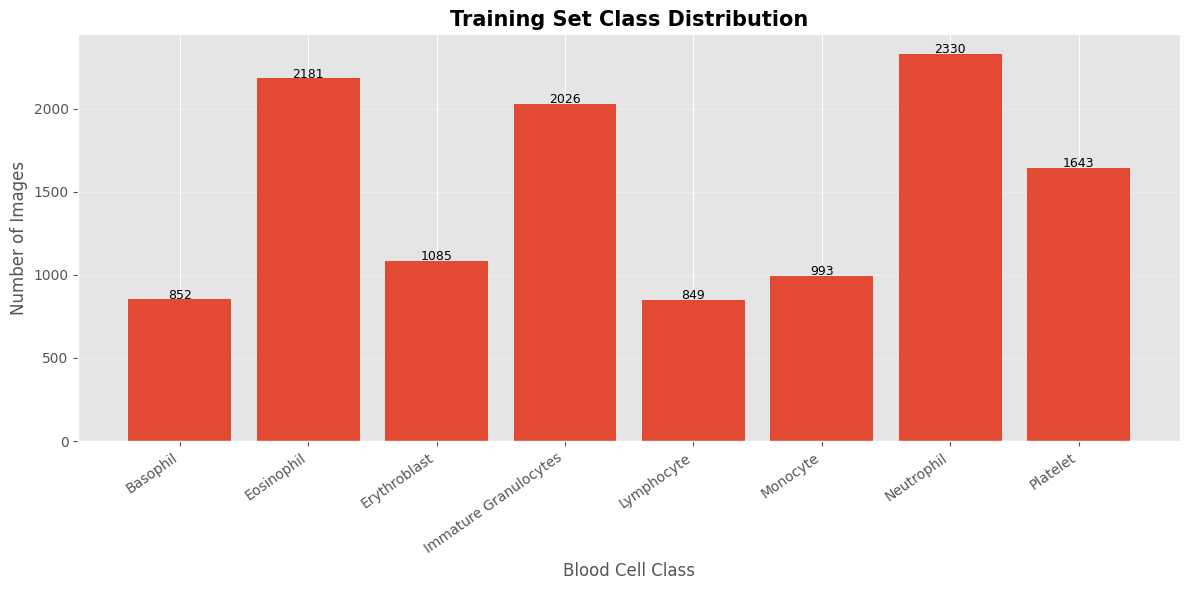

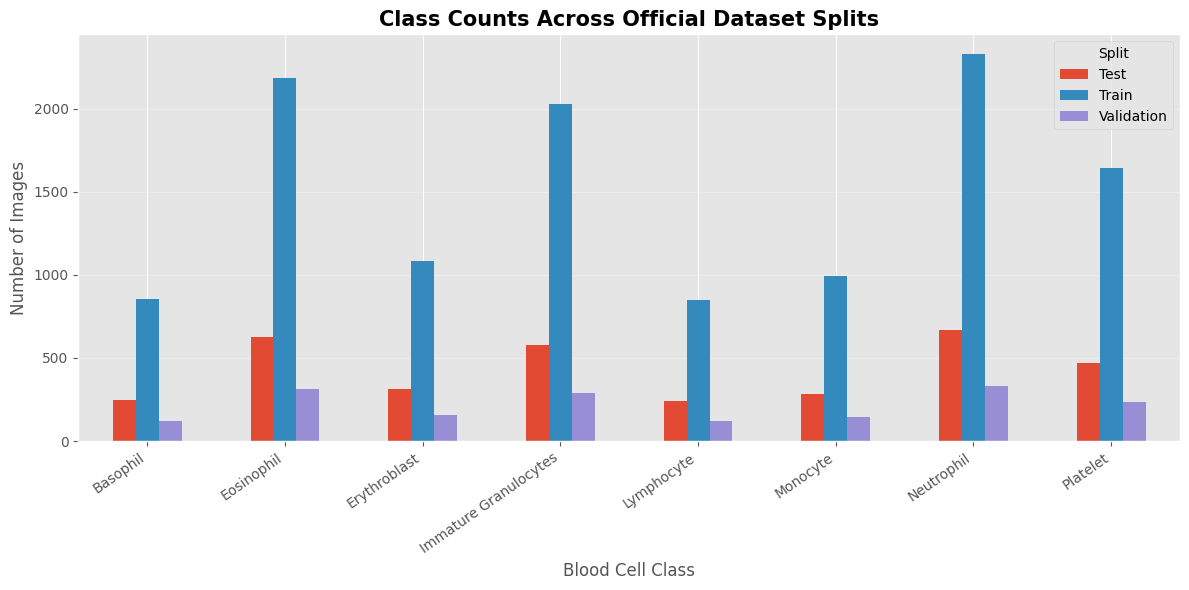

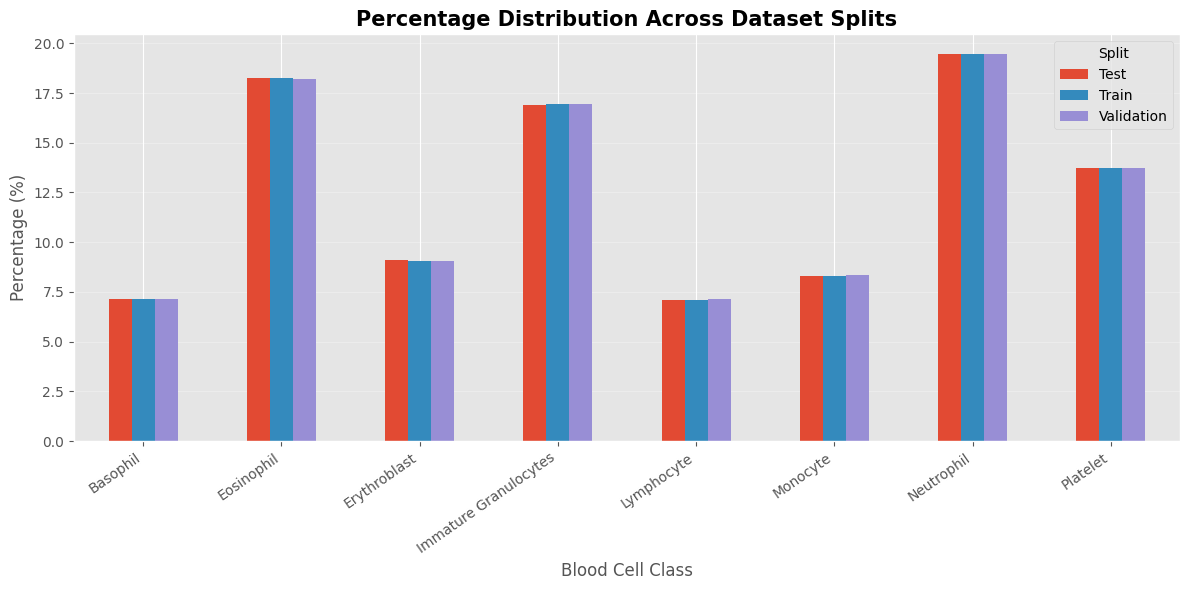

In [6]:
# ============================================================
# 6. Class Distribution Visualization
# ============================================================

plt.style.use("ggplot")

# ------------------------------------------------------------
# Training Set Distribution
# ------------------------------------------------------------

train_distribution = class_distribution_df[
    class_distribution_df["Split"] == "Train"
].copy()

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    train_distribution["Class"],
    train_distribution["Count"]
)

ax.set_title(
    "Training Set Class Distribution",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Blood Cell Class")
ax.set_ylabel("Number of Images")

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=35, ha="right")

# value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height+5,
        f"{int(height)}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "train_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Split-wise Class Count Comparison
# ------------------------------------------------------------

split_count_pivot = class_distribution_df.pivot(
    index="Class",
    columns="Split",
    values="Count"
).loc[list(LABEL_MAP.values())]

ax = split_count_pivot.plot(
    kind="bar",
    figsize=(12,6)
)

ax.set_title(
    "Class Counts Across Official Dataset Splits",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Blood Cell Class")
ax.set_ylabel("Number of Images")

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "split_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Split-wise Percentage Comparison
# ------------------------------------------------------------

split_percentage_pivot = class_distribution_df.pivot(
    index="Class",
    columns="Split",
    values="Percentage"
).loc[list(LABEL_MAP.values())]

ax = split_percentage_pivot.plot(
    kind="bar",
    figsize=(12,6)
)

ax.set_title(
    "Percentage Distribution Across Dataset Splits",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Blood Cell Class")
ax.set_ylabel("Percentage (%)")

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "split_class_percentages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The training set contains samples from all eight blood-cell classes, indicating that every class is represented in the learning process.

The comparison across the Train, Validation, and Test splits shows that the official MedMNIST split preserves a very similar class distribution. This consistency reduces the risk of distribution shift between dataset splits and enables fair model evaluation.

Although the dataset is relatively balanced, small differences exist between the largest and smallest classes. Therefore, evaluation metrics such as **Macro-F1 Score** and **Per-Class Recall** should be reported alongside overall accuracy during model evaluation.

## 6A. Overall Class Distribution

To complement the bar-chart analysis, the overall class distribution is visualized using a pie chart.

This figure provides an intuitive overview of the proportion of each blood-cell class in the complete BloodMNIST dataset. It helps identify whether any class dominates the dataset and supports the imbalance analysis performed in the previous section.

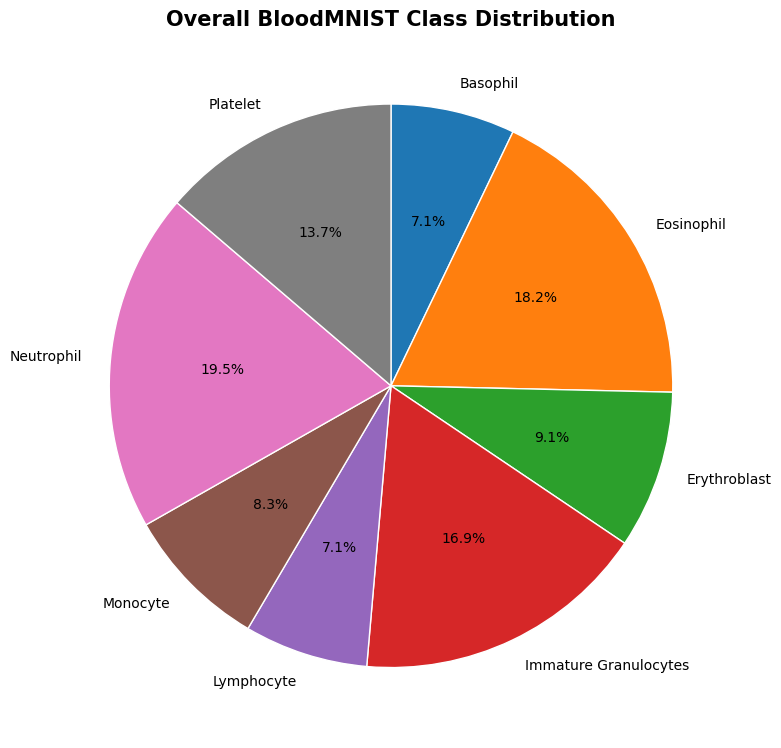

In [7]:
# ============================================================
# 6A. Overall Class Distribution (Pie Chart)
# ============================================================

overall_counts = np.concatenate([
    train_labels,
    val_labels,
    test_labels
])

count_series = pd.Series(overall_counts).value_counts().sort_index()

labels = [LABEL_MAP[i] for i in count_series.index]

plt.figure(figsize=(8,8))

colors = plt.cm.tab10.colors[:len(labels)]

plt.pie(
    count_series.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
    
)

plt.title(
    "Overall BloodMNIST Class Distribution",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "overall_class_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 7. Visual Inspection of Training Samples

## Objective

Visual inspection is an important part of Exploratory Data Analysis (EDA). It helps verify that the dataset has been loaded correctly and provides an initial understanding of the visual appearance of each blood-cell class.

In this section, four randomly selected training images from each BloodMNIST class are displayed.

The visualization allows us to examine:

- intra-class variation (differences within the same class),
- inter-class variation (differences between classes),
- staining variation,
- colour consistency,
- cell morphology,
- image quality.

This is only a qualitative inspection and does not measure model performance.

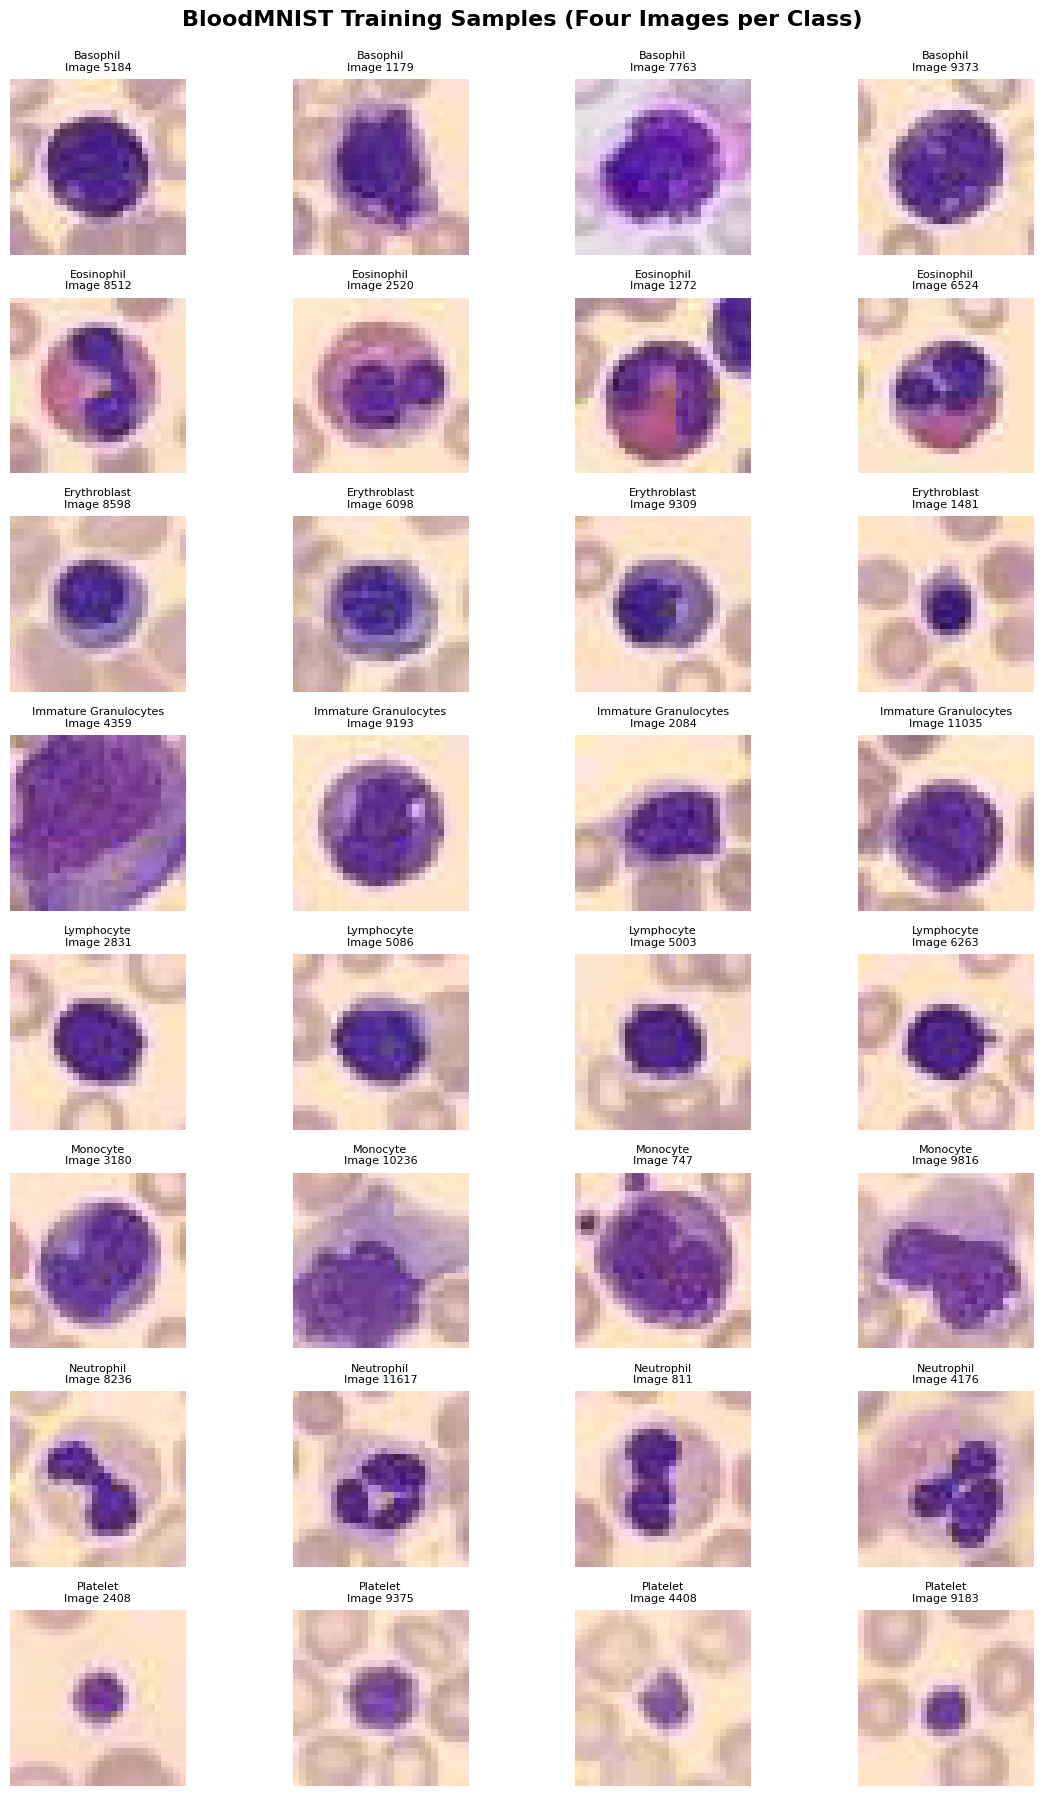

In [8]:
# ============================================================
# 7. Labelled Training Samples
# ============================================================

SAMPLES_PER_CLASS = 4

fig, axes = plt.subplots(
    nrows=len(LABEL_MAP),
    ncols=SAMPLES_PER_CLASS,
    figsize=(12, 18)
)

for row, (label_id, class_name) in enumerate(LABEL_MAP.items()):

    candidate_indices = np.flatnonzero(train_labels == label_id)

    # Fixed random selection for reproducibility
    chosen_indices = rng.choice(
        candidate_indices,
        size=SAMPLES_PER_CLASS,
        replace=False
    )

    for col, image_index in enumerate(chosen_indices):

        axes[row, col].imshow(train_images[image_index])

        axes[row, col].set_title(
            f"{class_name}\nImage {image_index}",
            fontsize=8
        )

        axes[row, col].axis("off")

plt.suptitle(
    "BloodMNIST Training Samples (Four Images per Class)",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "labelled_training_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# 7A. Interpretation
# ============================================================

print("="*70)
print("EDA Interpretation")
print("="*70)

print("""
• Four representative training images were visualized for each of the eight BloodMNIST classes.

• Considerable morphological differences can be observed across classes,
  while noticeable appearance variation also exists within individual classes.

• Differences in staining intensity, colour, cell size, and nucleus shape
  suggest that discriminative local image features will be important for
  accurate classification.

• These observations motivate the use of a CNN to capture local texture,
  followed by an attention mechanism to emphasize informative regions,
  before constructing a graph representation for GCN-based learning.
""")

EDA Interpretation

• Four representative training images were visualized for each of the eight BloodMNIST classes.

• Considerable morphological differences can be observed across classes,
  while noticeable appearance variation also exists within individual classes.

• Differences in staining intensity, colour, cell size, and nucleus shape
  suggest that discriminative local image features will be important for
  accurate classification.

• These observations motivate the use of a CNN to capture local texture,
  followed by an attention mechanism to emphasize informative regions,
  before constructing a graph representation for GCN-based learning.



# 8. Per-Class Mean (Prototype) Images

## Objective

The mean image of each BloodMNIST class is computed by averaging all training images belonging to that class.

These prototype images summarize the overall colour distribution, staining pattern, and spatial appearance of each class.

Unlike individual samples, mean images highlight consistent visual characteristics shared by most images within a class.

This analysis provides an intuitive understanding of class similarity before designing the proposed CNN–Attention–GCN architecture.

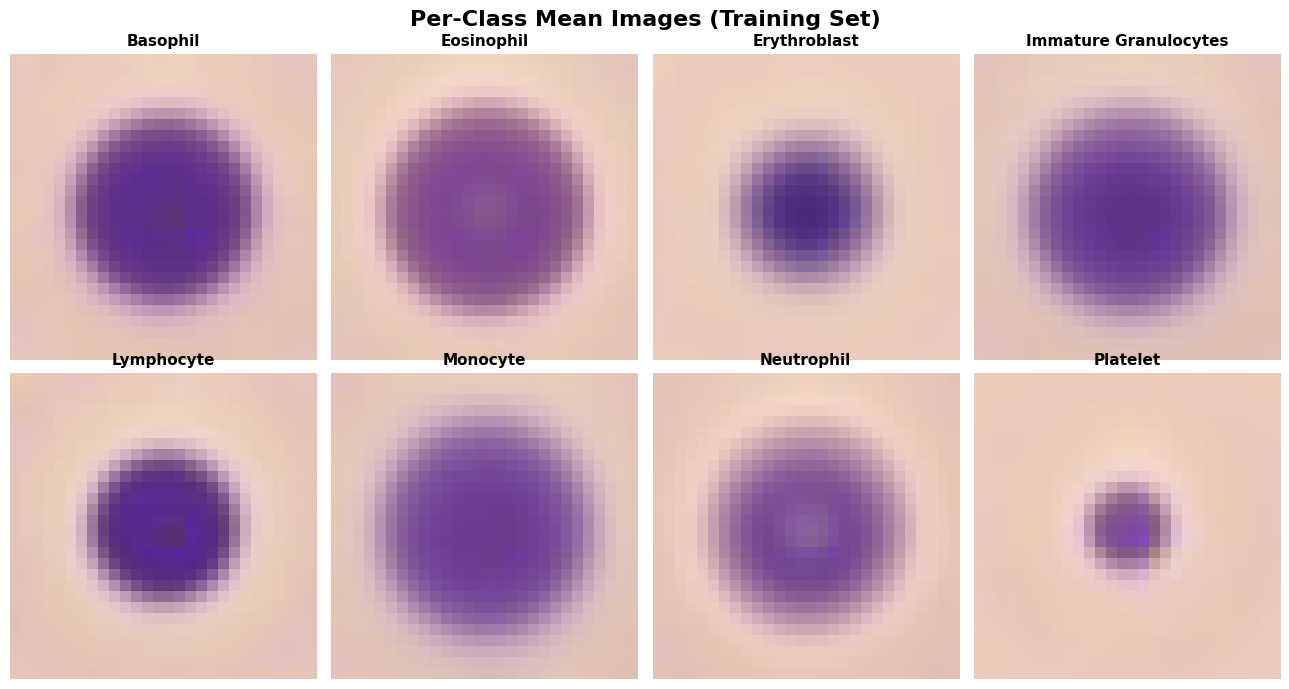

In [10]:
# ============================================================
# 8. Per-Class Mean Images (Class Prototypes)
# ============================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(13,7)
)

class_mean_images = {}

for axis, (label_id, class_name) in zip(
    axes.ravel(),
    LABEL_MAP.items()
):

    class_images = train_images[
        train_labels == label_id
    ].astype(np.float32)

    mean_image = class_images.mean(axis=0) / 255.0

    class_mean_images[label_id] = mean_image

    axis.imshow(
        np.clip(mean_image,0,1)
    )

    axis.set_title(
        class_name,
        fontsize=11,
        fontweight="bold"
    )

    axis.axis("off")

plt.suptitle(
    "Per-Class Mean Images (Training Set)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"class_mean_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# 8A. Interpretation
# ============================================================

print("="*70)
print("EDA Interpretation")
print("="*70)

print("""
• Each prototype image represents the average appearance of all training
  images belonging to one BloodMNIST class.

• The prototype images reveal common colour distributions and broad
  morphological patterns shared within each class.

• Some classes exhibit visually similar global appearances, suggesting
  that global colour information alone may not be sufficient for reliable
  classification.

• This observation supports the proposed CNN–Attention–GCN architecture,
  where CNN extracts local features, attention highlights informative
  regions, and GCN models spatial relationships among local regions.
""")

EDA Interpretation

• Each prototype image represents the average appearance of all training
  images belonging to one BloodMNIST class.

• The prototype images reveal common colour distributions and broad
  morphological patterns shared within each class.

• Some classes exhibit visually similar global appearances, suggesting
  that global colour information alone may not be sufficient for reliable
  classification.

• This observation supports the proposed CNN–Attention–GCN architecture,
  where CNN extracts local features, attention highlights informative
  regions, and GCN models spatial relationships among local regions.



# 9. Pixel Intensity and RGB Channel Analysis

This section analyzes the pixel-value distribution of the BloodMNIST dataset.

The analysis includes:

- Overall pixel statistics for each official split
- RGB channel mean and standard deviation
- Pixel intensity histogram
- Individual Red, Green and Blue channel distributions

These analyses help determine whether color distributions are consistent across the dataset and provide useful evidence for designing the CNN feature extractor.
The computed statistics will also be useful for image normalization during model development in Task 2.

,Split,Overall Mean,Overall Std,Overall Median,Overall Min,Overall Max,Red Mean,Red Std,Green Mean,Green Std,Blue Mean,Blue Std
0,Train,182.766998,52.769001,194.0,0.0,255.0,202.559006,54.986000,168.212997,61.609001,177.529007,30.062
1,Validation,182.802002,52.534000,194.0,0.0,255.0,202.572006,54.694000,168.268997,61.321999,177.563995,29.969
2,Test,182.699005,52.819000,194.0,0.0,255.0,202.485001,55.033001,168.130997,61.667999,177.481995,30.115


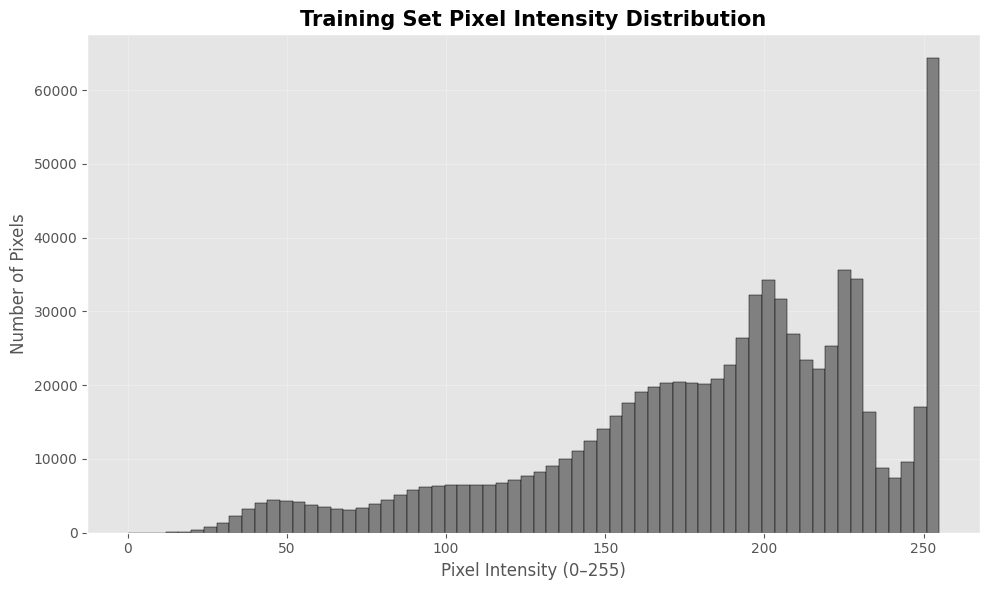

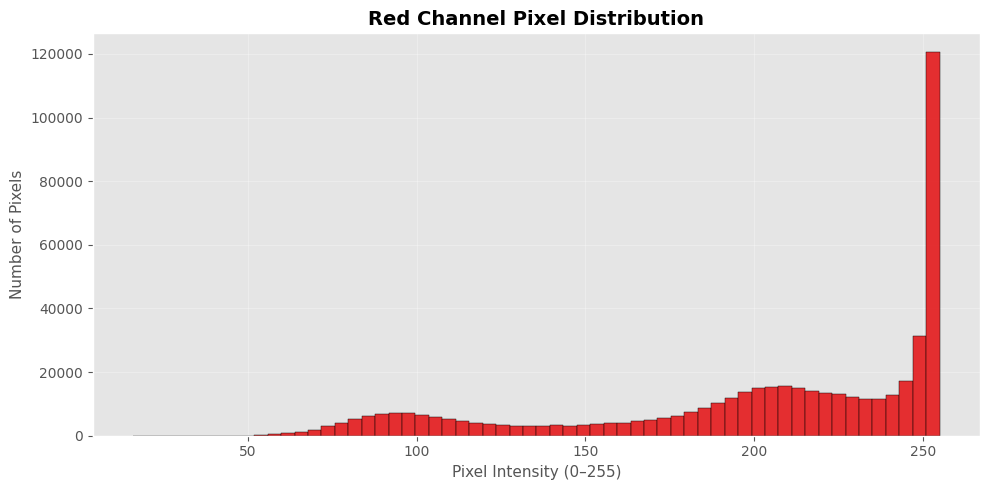

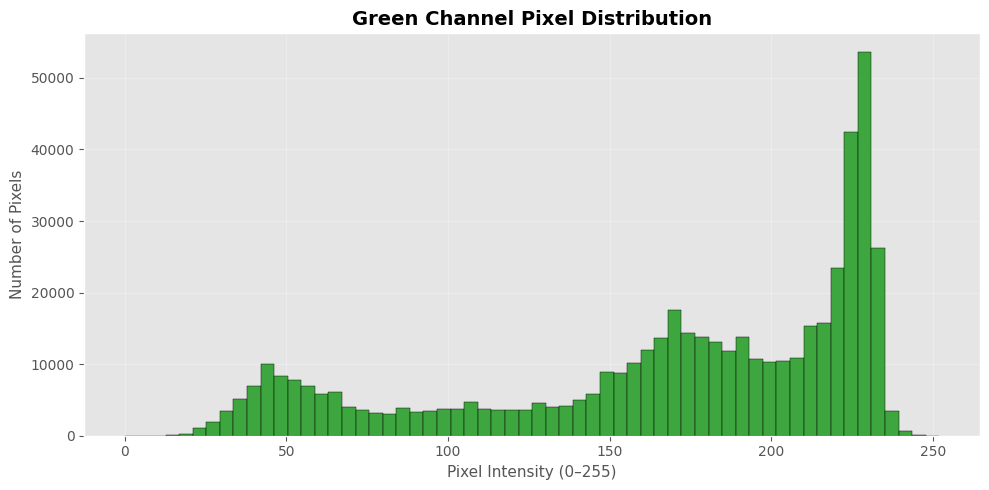

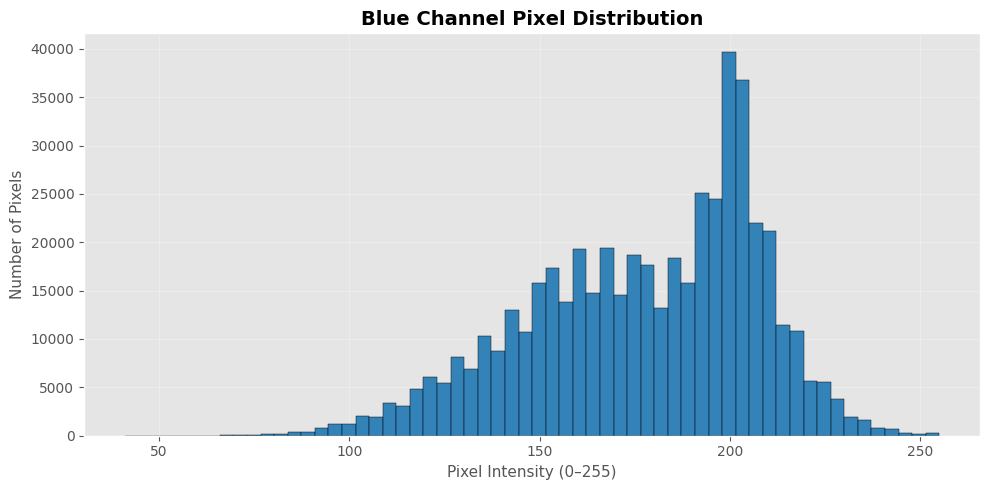

In [12]:
# ============================================================
# 9. Pixel Intensity and RGB Channel Analysis
# ============================================================

channel_names = ["Red", "Green", "Blue"]

pixel_stat_records = []

for split_name, (images, _) in SPLITS.items():

    images_float = images.astype(np.float32)

    record = {
        "Split": split_name,
        "Overall Mean": images_float.mean(),
        "Overall Std": images_float.std(),
        "Overall Median": np.median(images_float),
        "Overall Min": images_float.min(),
        "Overall Max": images_float.max(),
    }

    for c, name in enumerate(channel_names):

        channel = images_float[..., c]

        record[f"{name} Mean"] = channel.mean()
        record[f"{name} Std"] = channel.std()

    pixel_stat_records.append(record)

pixel_statistics_df = pd.DataFrame(pixel_stat_records)

display(pixel_statistics_df.round(3))

pixel_statistics_df.to_csv(
    TABLE_DIR / "pixel_channel_statistics.csv",
    index=False
)

# ============================================================
# Overall Pixel Histogram
# ============================================================

plt.style.use("ggplot")

flat_pixels = train_images.reshape(-1)

sample_size = min(800000, flat_pixels.size)

sample_idx = rng.choice(
    flat_pixels.size,
    sample_size,
    replace=False
)

plt.figure(figsize=(10,6))

plt.hist(
    flat_pixels[sample_idx],
    bins=64,
    color="gray",
    edgecolor="black",
    linewidth=0.35
)

plt.title(
    "Training Set Pixel Intensity Distribution",
    fontsize=15,
    weight="bold",
)

plt.xlabel("Pixel Intensity (0–255)", fontsize=12)

plt.ylabel("Number of Pixels", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "overall_pixel_distribution.png",
    dpi=300,
)

plt.show()

# ============================================================
# RGB Channel Histograms
# ============================================================

colors = {
    "Red": "#e41a1c",
    "Green": "#2ca02c",
    "Blue": "#1f77b4",
}

for c, name in enumerate(channel_names):

    pixels = train_images[..., c].reshape(-1)

    sample_size = min(500000, pixels.size)

    idx = rng.choice(
        pixels.size,
        sample_size,
        replace=False,
    )

    plt.figure(figsize=(10,5))

    plt.hist(
        pixels[idx],
        bins=60,
        color=colors[name],
        edgecolor="black",
        linewidth=0.35,
        alpha=0.9,
    )

    plt.title(
        f"{name} Channel Pixel Distribution",
        fontsize=14,
        weight="bold",
    )

    plt.xlabel(
        "Pixel Intensity (0–255)",
        fontsize=11,
    )

    plt.ylabel(
        "Number of Pixels",
        fontsize=11,
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{name.lower()}_channel_distribution.png",
        dpi=300,
    )

    plt.show()

### Interpretation

- The RGB histograms show that BloodMNIST images have different intensity distributions across the three color channels.
- The red channel contains more high-intensity pixels, while the green and blue channels exhibit different spread and peak locations.
- These differences indicate staining and color variation among blood-cell images.
- Such color information is expected to help the CNN learn discriminative low-level features before graph construction.

## 9A. RGB Channel Mean Comparison

###  Purpose

This section compares the average Red, Green, and Blue (RGB) channel intensities across the official Training, Validation, and Test splits.

The objective is to verify whether the three official dataset splits have similar colour distributions. Consistent RGB statistics indicate that the official MedMNIST split is balanced with respect to global colour characteristics and does not introduce obvious colour bias between training and evaluation data.

### What this figure shows

- Average Red-channel intensity
- Average Green-channel intensity
- Average Blue-channel intensity
- Comparison across Train, Validation, and Test splits

### Why this is important

If one split had noticeably different RGB characteristics, a model could unintentionally learn split-specific colour information instead of medically meaningful cellular morphology.

Similar RGB means across the official splits support the fairness of the benchmark and indicate consistent staining and image acquisition conditions.

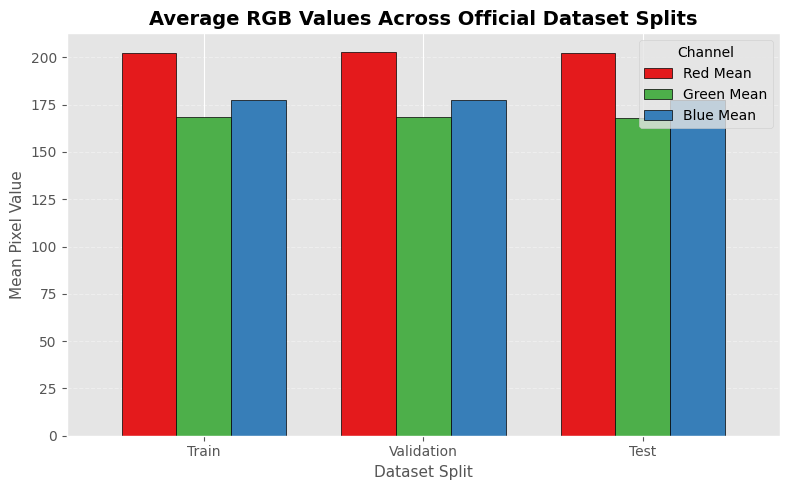

In [13]:
# ============================================================
# 9A. RGB Mean Comparison
# ============================================================

rgb_mean_df = pixel_statistics_df[
    [
        "Split",
        "Red Mean",
        "Green Mean",
        "Blue Mean",
    ]
].set_index("Split")

ax = rgb_mean_df.plot(
    kind="bar",
    figsize=(8, 5),
    color=[
        "#e41a1c",   # Red
        "#4daf4a",   # Green
        "#377eb8",   # Blue
    ],
    edgecolor="black",
    width=0.75,
)

plt.title(
    "Average RGB Values Across Official Dataset Splits",
    fontsize=14,
    weight="bold",
)

plt.xlabel("Dataset Split", fontsize=11)
plt.ylabel("Mean Pixel Value", fontsize=11)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

plt.legend(
    title="Channel",
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rgb_mean_comparison.png",
    dpi=300,
)

plt.show()

# 10. Image Quality and Appearance Analysis

In this section, several image-level quality and appearance metrics are computed for every image in the official BloodMNIST dataset.

These metrics are descriptive EDA features only. They are **not** used for training or evaluating any machine learning model.

The computed metrics include:

- **Brightness** – Average grayscale intensity
- **Contrast** – Standard deviation of grayscale intensity
- **Blur Score** – Variance of the Laplacian (higher usually indicates a sharper image)
- **Entropy** – Amount of information or texture present in the image
- **Edge Strength** – Average local intensity change
- **Center–Border Gap** – Difference between the center region and border region

These measurements help identify:

- image appearance variation
- potential low-quality images
- staining differences
- possible outliers

The computed metrics will be used in the following EDA sections for quality visualization and dataset comparison.

In [14]:
# ============================================================
# 10. Image-Level Quality and Appearance Metrics
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Entropy Calculation
# ------------------------------------------------------------

def calculate_entropy(gray_image_uint8):
    histogram = np.bincount(
        gray_image_uint8.ravel(),
        minlength=256
    )

    probabilities = histogram.astype(np.float64)
    probabilities /= probabilities.sum()

    probabilities = probabilities[probabilities > 0]

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return float(entropy)


# ------------------------------------------------------------
# Metric Calculation
# ------------------------------------------------------------

def build_image_metrics(images, labels, split_name):

    images = images.astype(np.float32)

    gray = (
        0.299 * images[...,0] +
        0.587 * images[...,1] +
        0.114 * images[...,2]
    )

    brightness = gray.mean(axis=(1,2))
    contrast = gray.std(axis=(1,2))

    red_mean = images[...,0].mean(axis=(1,2))
    green_mean = images[...,1].mean(axis=(1,2))
    blue_mean = images[...,2].mean(axis=(1,2))

    blur_scores = np.zeros(len(images))
    entropy_scores = np.zeros(len(images))
    edge_strengths = np.zeros(len(images))
    center_border_gap = np.zeros(len(images))

    for i, gray_image in enumerate(gray):

        # -------------------------
        # Laplacian Blur
        # -------------------------

        laplacian = (
            -4*gray_image[1:-1,1:-1]
            + gray_image[:-2,1:-1]
            + gray_image[2:,1:-1]
            + gray_image[1:-1,:-2]
            + gray_image[1:-1,2:]
        )

        blur_scores[i] = laplacian.var()

        # -------------------------
        # Entropy
        # -------------------------

        gray_uint8 = np.clip(
            np.rint(gray_image),
            0,
            255
        ).astype(np.uint8)

        entropy_scores[i] = calculate_entropy(gray_uint8)

        # -------------------------
        # Edge Strength
        # -------------------------

        dx = np.abs(np.diff(gray_image, axis=1)).mean()
        dy = np.abs(np.diff(gray_image, axis=0)).mean()

        edge_strengths[i] = (dx + dy) / 2

        # -------------------------
        # Center Border Difference
        # -------------------------

        center = gray_image[7:21,7:21]

        border_mask = np.ones((28,28), dtype=bool)
        border_mask[4:24,4:24] = False

        border = gray_image[border_mask]

        center_border_gap[i] = abs(
            center.mean() - border.mean()
        )

    df = pd.DataFrame({

        "Split": split_name,

        "Image Index": np.arange(len(images)),

        "Label ID": labels.astype(int),

        "Class": [
            LABEL_MAP[int(i)]
            for i in labels
        ],

        "Brightness": brightness,

        "Contrast": contrast,

        "Blur Score": blur_scores,

        "Entropy": entropy_scores,

        "Edge Strength": edge_strengths,

        "Center-Border Gap": center_border_gap,

        "Red Mean": red_mean,

        "Green Mean": green_mean,

        "Blue Mean": blue_mean

    })

    return df.round(3)


# ============================================================
# Calculate Metrics
# ============================================================

metric_frames = []

for split_name, (images, labels) in SPLITS.items():

    print(f"Processing {split_name}...")

    metric_frames.append(

        build_image_metrics(
            images,
            labels,
            split_name
        )

    )

image_metrics_df = pd.concat(
    metric_frames,
    ignore_index=True
)

print()

print("="*70)
print("Image Metric Preview")
print("="*70)

display(image_metrics_df.head())

print()

print("Total Images :", len(image_metrics_df))

print()

print("="*70)
print("Summary Statistics")
print("="*70)

display(

image_metrics_df[
[
"Brightness",
"Contrast",
"Blur Score",
"Entropy",
"Edge Strength",
"Center-Border Gap"
]
].describe().round(3)

)

image_metrics_df.to_csv(
    TABLE_DIR/"image_level_metrics.csv",
    index=False
)

print()

print("Saved : image_level_metrics.csv")

Processing Train...
Processing Validation...
Processing Test...

Image Metric Preview


,Split,Image Index,Label ID,Class,Brightness,Contrast,Blur Score,Entropy,Edge Strength,Center-Border Gap,Red Mean,Green Mean,Blue Mean
0,Train,0,7,Platelet,206.630997,35.021000,836.476,6.143,11.141,10.813,229.761002,198.800995,186.278000
1,Train,1,3,Immature Granulocytes,153.102005,61.514999,1399.857,6.972,13.818,110.819,172.903000,139.987000,168.695999
2,Train,2,6,Neutrophil,190.162003,52.715000,1495.669,6.501,13.433,87.525,212.647003,180.686005,179.981995
3,Train,3,6,Neutrophil,174.501999,56.355999,2053.438,6.829,14.899,100.191,197.942993,162.550003,174.569000
4,Train,4,7,Platelet,199.455994,37.324001,730.860,6.298,10.542,44.881,222.304993,190.656998,184.834000



Total Images : 17092

Summary Statistics


,Brightness,Contrast,Blur Score,Entropy,Edge Strength,Center-Border Gap
count,17092.000,17092.000,17092.000,17092.000,17092.000,17092.000
mean,179.533,52.352,1521.892,6.579,12.999,88.268
std,15.382,9.899,553.058,0.432,2.220,33.554
min,96.578,17.079,116.030,2.889,2.852,0.025
25%,169.480,50.071,1167.875,6.354,11.899,78.087
50%,178.442,54.546,1559.028,6.678,13.358,96.756
75%,188.155,58.624,1881.823,6.897,14.489,111.060
max,225.459,76.559,3997.948,7.333,19.427,156.607



Saved : image_level_metrics.csv


## 10A. Overall Image Quality Summary

This section summarizes the image quality metrics across the official
Training, Validation, and Test splits.

The objective is to verify that the dataset has consistent image
characteristics before model development.

The reported values are descriptive statistics only and are **not**
used for filtering or modifying the official BloodMNIST dataset.

In [15]:
print(image_metrics_df.columns.tolist())

['Split', 'Image Index', 'Label ID', 'Class', 'Brightness', 'Contrast', 'Blur Score', 'Entropy', 'Edge Strength', 'Center-Border Gap', 'Red Mean', 'Green Mean', 'Blue Mean']


In [16]:
# ============================================================
# 10A. Overall Image Quality Summary
# ============================================================

quality_summary_df = (
    image_metrics_df
    .groupby("Split")[
        [
            "Brightness",
            "Contrast",
            "Blur Score",
            "Entropy",
            "Edge Strength",
            "Center-Border Gap",
        ]
    ]
    .agg(["mean", "std"])
    .round(3)
)

print("=" * 70)
print("OVERALL IMAGE QUALITY SUMMARY")
print("=" * 70)

display(quality_summary_df)

quality_summary_df.to_csv(
    TABLE_DIR / "overall_image_quality_summary.csv"
)

print(" Overall quality summary saved successfully.")

OVERALL IMAGE QUALITY SUMMARY


Brightness           Contrast        Blur Score          Entropy        Edge Strength        Center-Border Gap        
                  mean     std       mean    std       mean      std    mean    std          mean    std              mean     std
Split                                                                                                                             
Test        179.468994  15.380  52.421001  9.929   1529.404  557.766   6.582  0.429        13.028  2.193            88.345  33.661
Train       179.544006  15.439  52.352001  9.904   1518.534  550.999   6.577  0.434        12.984  2.226            88.216  33.570
Validation  179.585007  14.989  52.210999  9.802   1530.340  558.036   6.591  0.424        13.053  2.233            88.473  33.252

 Overall quality summary saved successfully.


### Interpretation

- The average image quality metrics are comparable across the Training,
  Validation, and Test splits.

- No substantial distribution shift is observed based on brightness,
  contrast, blur, entropy, or edge information.

- These findings support the use of the official MedMNIST dataset split
  without modification during Task 1.

# 11. Class-wise Image Quality Analysis

This section compares image-quality characteristics among the eight
BloodMNIST classes using the official **training split**.

For each class, the following metrics are analyzed:

- Brightness
- Contrast
- Blur Score
- Entropy
- Edge Strength
- Center-Border Gap

The summary statistics (mean, standard deviation, and median) provide
an overview of each class, while boxplots illustrate the variability
within each class.

These analyses are descriptive only and do not indicate model
performance.

CLASS-WISE IMAGE QUALITY SUMMARY


Brightness                       Contrast                   Blur Score                    Entropy                \
                                                 mean     std      median       mean    std     median       mean      std    median    mean    std median   
Split      Label ID Class                                                                                                                                    
Test       0        Basophil               168.542007   8.838  169.300003  61.821999  4.113  61.688000   2183.719  513.108  2116.790   6.780  0.258  6.822   
           1        Eosinophil             174.123993   7.520  174.819000  56.219002  3.971  56.534000   1723.810  326.301  1698.556   6.795  0.271  6.854   
           2        Erythroblast           190.955002  11.177  193.350998  50.817001  6.467  49.820999   1112.196  467.351  1002.115   6.243  0.433  6.276   
           3        Immature Granulocytes  167.360992  12.893  169.352005  58.525002  4.877  58.316002   1610.134  475.100  1537.138   6.787  0.265  6.823   
           4        Lymphocyte             183.434006   5.923  183.156006  57.338001  2.541  57.247002   1636.317  301.657  1620.703   6.503  0.246  6.525   
           5        Monocyte               164.421005   7.532  164.753006  56.355999  5.592  56.312000   1594.100  405.840  1550.237   6.903  0.203  6.947   
           6        Neutrophil             180.764999   7.445  181.220001  52.320000  2.789  52.257000   1755.841  355.475  1722.677   6.642  0.236  6.674   
           7        Platelet               204.759003   5.815  204.910004  31.261999  3.945  30.969000    692.992  252.712   660.430   5.927  0.391  5.985   
Train      0        Basophil               169.343002   9.003  169.598007  61.894001  3.651  61.993000   2109.866  463.571  2100.350   6.770  0.251  6.816   
           1        Eosinophil             174.240005   7.466  174.865005  56.209000  3.814  56.581001   1727.659  329.957  1707.583   6.794  0.268  6.847   
           2        Erythroblast           191.307999  10.286  193.246994  50.757000  6.593  49.910000   1085.777  427.180  1001.958   6.238  0.416  6.269   
           3        Immature Granulocytes  167.356003  12.762  169.121994  58.487000  4.827  58.299000   1613.726  475.699  1529.654   6.789  0.270  6.841   
           4        Lymphocyte             183.345993   7.153  183.416000  57.403999  3.120  57.535999   1625.613  318.392  1607.103   6.456  0.322  6.517   
           5        Monocyte               163.942993   7.936  163.914001  55.648998  5.669  55.900002   1599.783  417.538  1551.445   6.918  0.190  6.953   
           6        Neutrophil             180.783997   7.513  181.414993  52.269001  2.705  52.285999   1747.062  340.817  1730.625   6.645  0.230  6.665   
           7        Platelet               204.843994   6.423  205.287003  31.285000  4.111  30.896999    674.168  247.437   642.219   5.913  0.387  5.964   
Validation 0        Basophil               169.300995   8.814  168.845001  61.925999  3.770  61.960999   2199.774  440.403  2184.675   6.768  0.266  6.825   
           1        Eosinophil             173.988007   7.180  175.102997  56.005001  3.728  56.412998   1759.867  368.832  1722.394   6.819  0.260  6.862   
           2        Erythroblast           190.552994  11.023  192.143997  50.765999  6.259  49.875999   1092.655  420.294  1042.221   6.281  0.431  6.336   
           3        Immature Granulocytes  168.878006  12.334  170.334000  58.132000  4.261  57.826000   1571.165  450.342  1496.108   6.773  0.273  6.808   
           4        Lymphocyte             182.770996   6.180  182.632004  57.328999  3.096  56.928001   1615.079  322.792  1604.392   6.493  0.287  6.552   
           5        Monocyte               163.654999   7.646  163.690994  55.527000  5.542  56.064999   1608.504  424.343  1538.453   6.935  0.189  6.958   
           6        Neutrophil             180.876007   6.841  181.339005  52.161999  2.814  

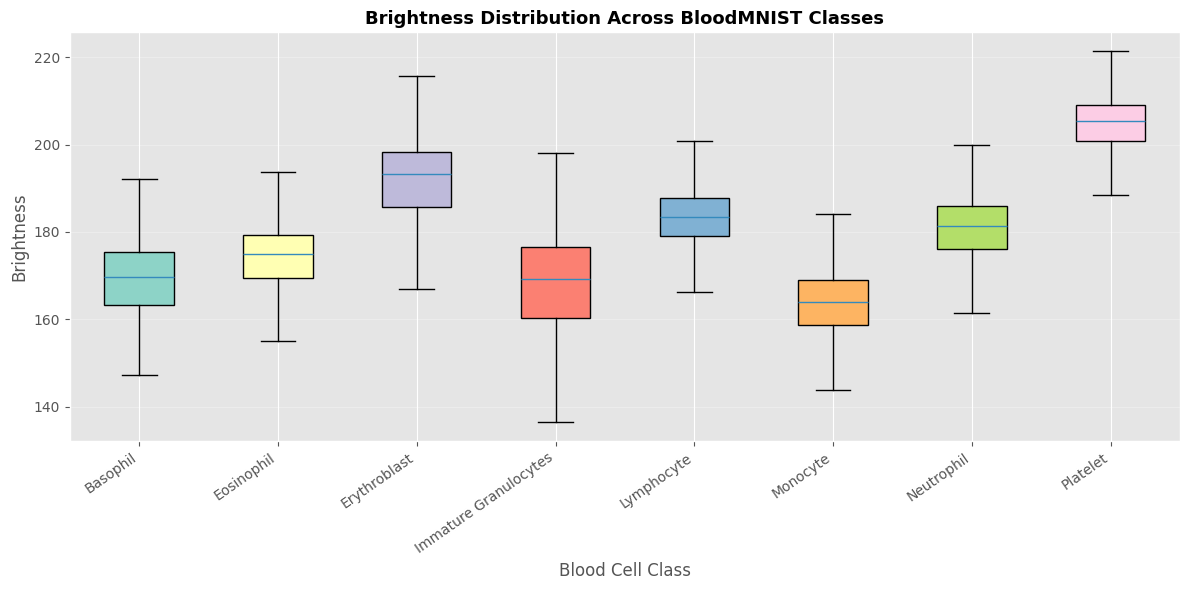

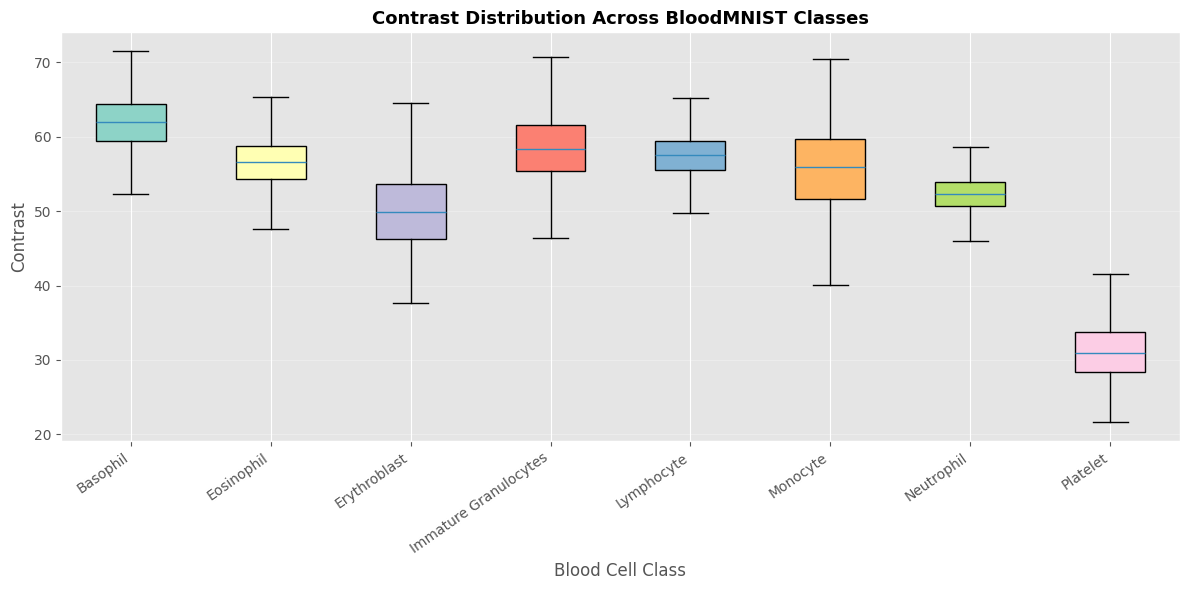

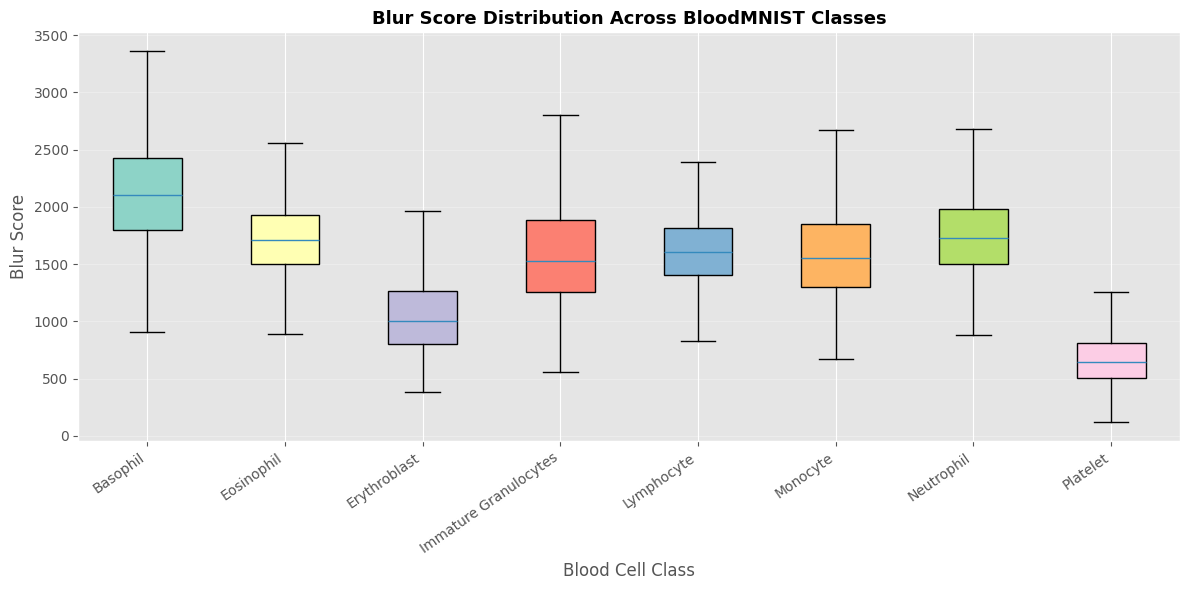

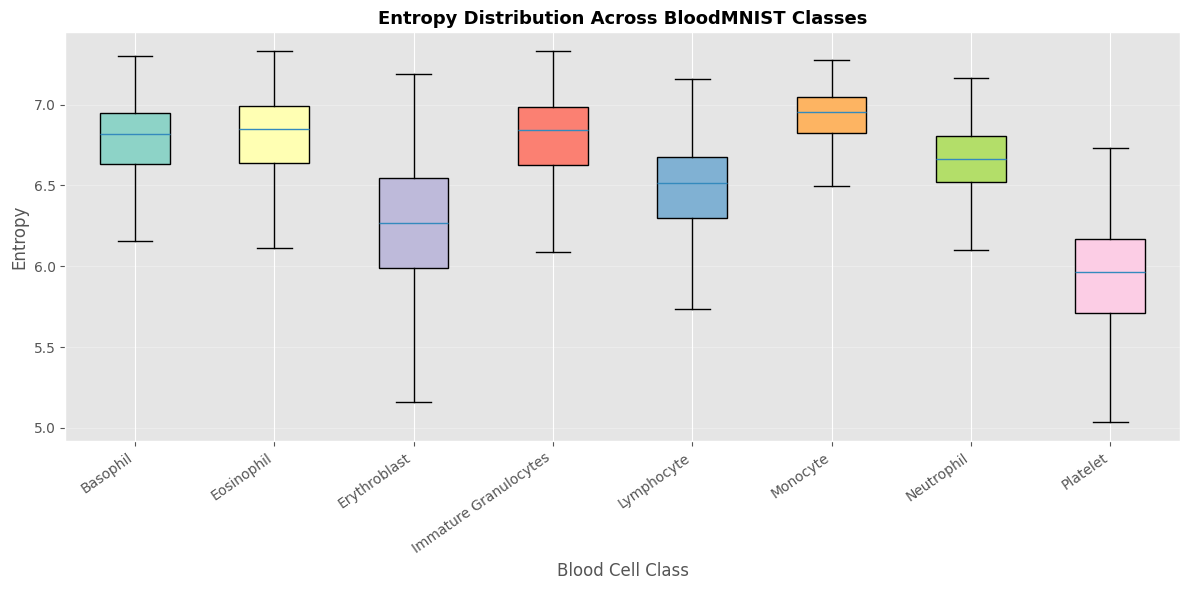

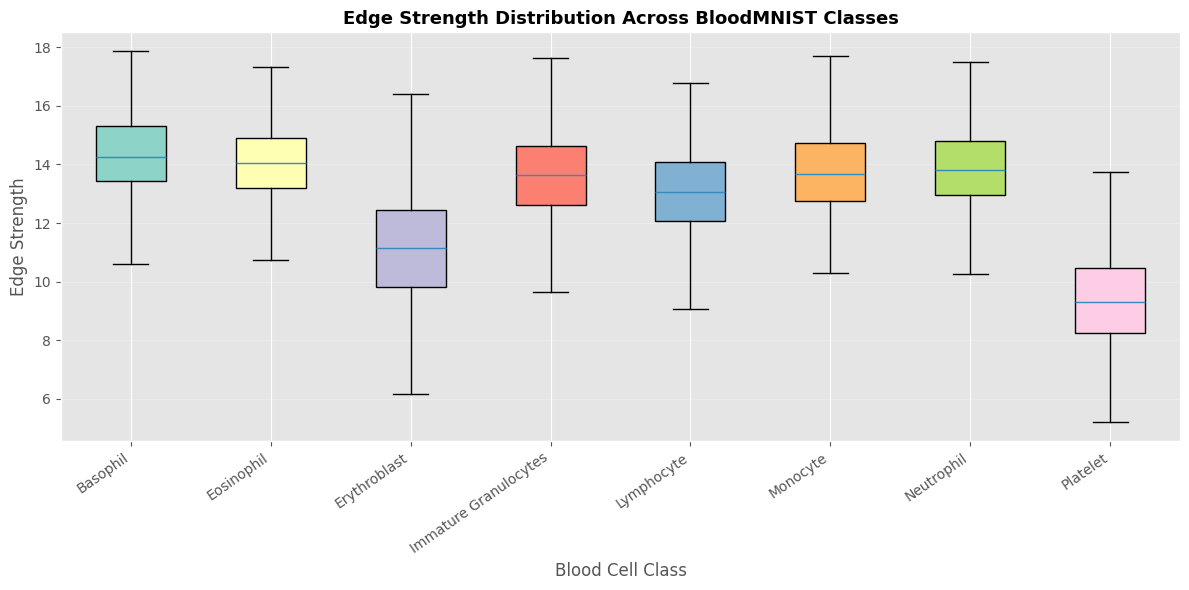

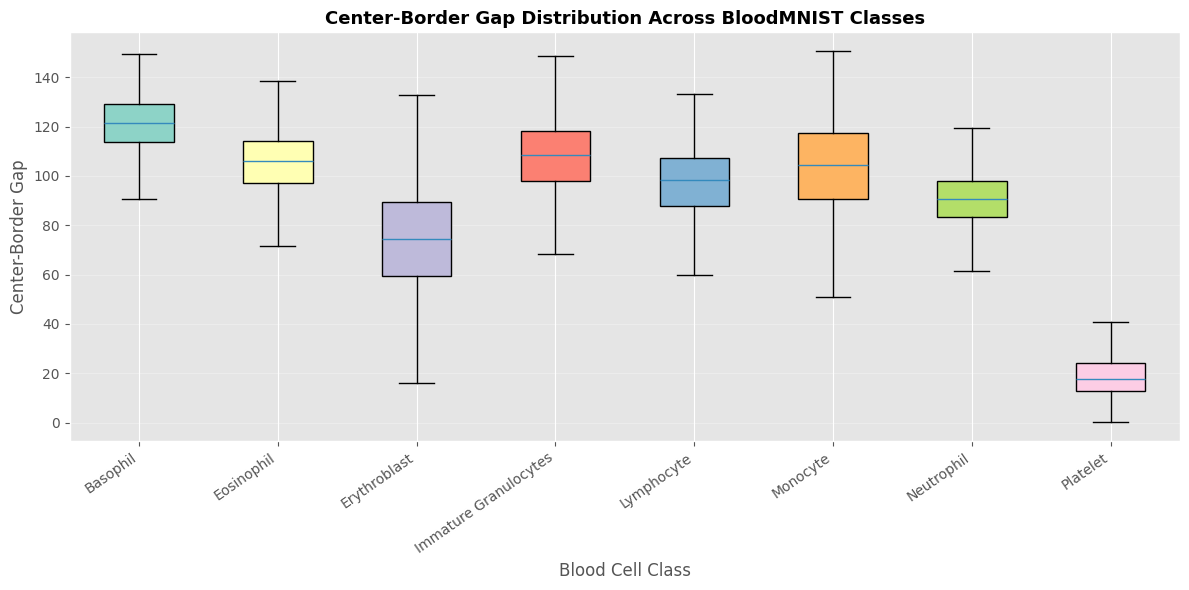

✓ Class-wise quality analysis completed.


In [17]:
# ============================================================
# 11. Class-wise Image Quality Analysis
# ============================================================

QUALITY_METRICS = [
    "Brightness",
    "Contrast",
    "Blur Score",
    "Entropy",
    "Edge Strength",
    "Center-Border Gap",
]

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

class_metric_summary_df = (
    image_metrics_df
    .groupby(["Split", "Label ID", "Class"])[QUALITY_METRICS]
    .agg(["mean", "std", "median"])
    .round(3)
)

print("=" * 70)
print("CLASS-WISE IMAGE QUALITY SUMMARY")
print("=" * 70)

display(class_metric_summary_df)

class_metric_summary_df.to_csv(
    TABLE_DIR / "class_metric_summary.csv"
)

# ------------------------------------------------------------
# Training-set visualization
# ------------------------------------------------------------

train_metrics_df = image_metrics_df[
    image_metrics_df["Split"] == "Train"
].copy()

for metric_name in QUALITY_METRICS:

    ordered_data = [
        train_metrics_df.loc[
            train_metrics_df["Class"] == class_name,
            metric_name,
        ].values
        for class_name in LABEL_MAP.values()
    ]

    plt.figure(figsize=(12,6))

    box = plt.boxplot(
        ordered_data,
        labels=list(LABEL_MAP.values()),
        patch_artist=True,
        showfliers=False,
    )

    # publication-style colors
    colors = plt.cm.Set3.colors

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    plt.title(f"{metric_name} Distribution Across BloodMNIST Classes",
              fontsize=13,
              weight="bold")

    plt.xlabel("Blood Cell Class")
    plt.ylabel(metric_name)

    plt.xticks(rotation=35, ha="right")

    plt.grid(axis="y", alpha=0.30)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"classwise_{metric_name.lower().replace(' ','_').replace('-','_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("✓ Class-wise quality analysis completed.")

### Interpretation

- The distributions of brightness, contrast, blur score, entropy,
  edge strength, and center-border gap vary across blood-cell classes.

- Some classes exhibit wider variability than others, indicating
  greater diversity in staining intensity, morphology, or local
  appearance.

- These observations suggest that both local image features and
  spatial relationships are important for discriminating visually
  similar blood-cell classes.

- The analysis is descriptive only and should not be interpreted as
  evidence of classification performance.

## 11A. Heatmap of Class-wise Quality Metrics

This heatmap summarizes the **average image-quality metrics** for each
BloodMNIST class using the official training set.

The visualization provides a compact comparison of brightness,
contrast, blur score, entropy, edge strength, and center-border gap
across all eight classes.

This is a descriptive visualization and should not be interpreted as a
measure of classification performance.

,Brightness,Contrast,Blur Score,Entropy,Edge Strength,Center-Border Gap
Class,,,,,,
Basophil,169.339996,61.889999,2109.87,6.77,14.32,119.66
Eosinophil,174.240005,56.209999,1727.66,6.79,14.09,103.97
Erythroblast,191.309998,50.759998,1085.78,6.24,11.17,76.42
Immature Granulocytes,167.360001,58.490002,1613.73,6.79,13.67,107.27
Lymphocyte,183.350006,57.400002,1625.61,6.46,13.10,96.69
Monocyte,163.940002,55.650002,1599.78,6.92,13.78,103.38
Neutrophil,180.779999,52.270000,1747.06,6.65,13.88,89.94
Platelet,204.839996,31.290001,674.17,5.91,9.37,19.31


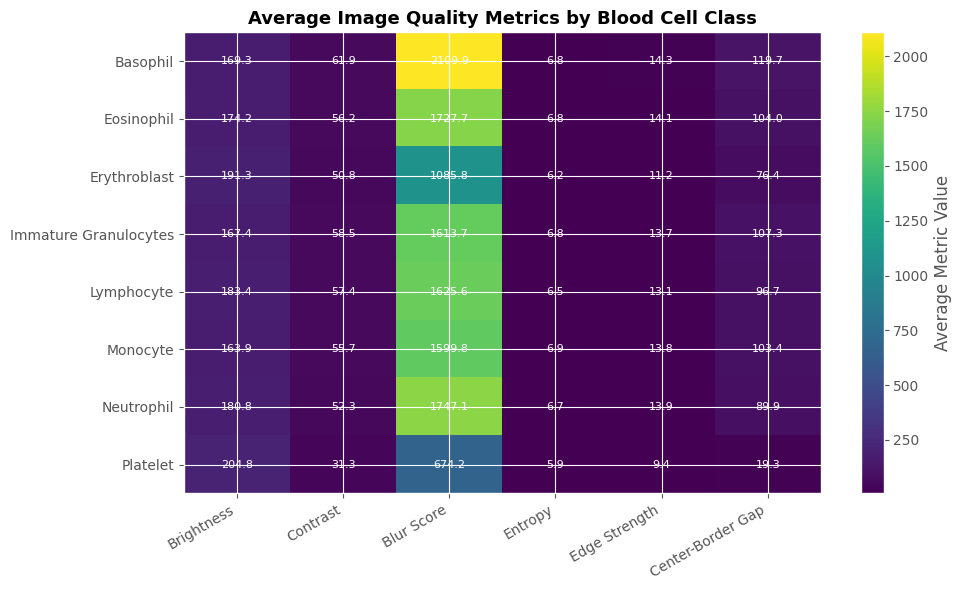

✓ Class quality heatmap generated successfully.


In [18]:
# ============================================================
# 11A. Heatmap of Class-wise Quality Metrics
# ============================================================

quality_metrics = [
    "Brightness",
    "Contrast",
    "Blur Score",
    "Entropy",
    "Edge Strength",
    "Center-Border Gap",
]

heatmap_df = (
    train_metrics_df
    .groupby("Class")[quality_metrics]
    .mean()
    .loc[list(LABEL_MAP.values())]
    .round(2)
)

display(heatmap_df)

heatmap_df.to_csv(
    TABLE_DIR / "class_quality_heatmap_values.csv"
)

# ------------------------------------------------------------
# Publication-style Heatmap (Matplotlib only)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="viridis"
)

# Axis labels
ax.set_xticks(np.arange(len(quality_metrics)))
ax.set_xticklabels(quality_metrics, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

# Write values inside cells
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_df.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )

cbar = plt.colorbar(im)
cbar.set_label("Average Metric Value")

plt.title(
    "Average Image Quality Metrics by Blood Cell Class",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_quality_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Class quality heatmap generated successfully.")

Interpretation

• Different blood-cell classes exhibit different brightness,
contrast and texture characteristics.

• Blur score and edge strength vary across classes,
indicating structural differences.

• These observations support extracting local spatial features
using CNN before graph construction.

• This figure is descriptive only and does not imply
classification performance.

#  12. Relative Quality and Potential Outlier Screening

This analysis identifies images that fall into the extreme 1% of the
training-set quality metric distributions.

The thresholds are derived **only from the official training set** and
are then applied to the training, validation, and test splits.

Flagged samples are considered **potential outliers only**.
No images are removed or modified during Task 1. Any decision regarding
data cleaning will be evaluated separately in later experiments.

In [19]:
# ============================================================
# 12. Relative Quality and Potential Outlier Screening
# ============================================================

# Use only the official training split to define thresholds
train_reference = image_metrics_df[
    image_metrics_df["Split"] == "Train"
]

quality_thresholds = {
    "Dark Threshold": train_reference["Brightness"].quantile(0.01),
    "Bright Threshold": train_reference["Brightness"].quantile(0.99),
    "Low Contrast Threshold": train_reference["Contrast"].quantile(0.01),
    "Low Blur Threshold": train_reference["Blur Score"].quantile(0.01),
    "Low Entropy Threshold": train_reference["Entropy"].quantile(0.01),
}

quality_thresholds_df = (
    pd.DataFrame(
        quality_thresholds.items(),
        columns=["Threshold", "Value"]
    )
    .round(3)
)

display(quality_thresholds_df)

# ------------------------------------------------------------
# Flag potential quality issues
# ------------------------------------------------------------

image_metrics_df["Potentially Dark"] = (
    image_metrics_df["Brightness"]
    <= quality_thresholds["Dark Threshold"]
)

image_metrics_df["Potentially Bright"] = (
    image_metrics_df["Brightness"]
    >= quality_thresholds["Bright Threshold"]
)

image_metrics_df["Potentially Low Contrast"] = (
    image_metrics_df["Contrast"]
    <= quality_thresholds["Low Contrast Threshold"]
)

image_metrics_df["Potentially Blurry"] = (
    image_metrics_df["Blur Score"]
    <= quality_thresholds["Low Blur Threshold"]
)

image_metrics_df["Potentially Low Entropy"] = (
    image_metrics_df["Entropy"]
    <= quality_thresholds["Low Entropy Threshold"]
)

flag_columns = [
    "Potentially Dark",
    "Potentially Bright",
    "Potentially Low Contrast",
    "Potentially Blurry",
    "Potentially Low Entropy",
]

quality_summary_df = (
    image_metrics_df
    .groupby("Split")[flag_columns]
    .sum()
    .astype(int)
    .reset_index()
)

display(quality_summary_df)

# ------------------------------------------------------------
# Percentage summary
# ------------------------------------------------------------

split_sizes = image_metrics_df.groupby("Split").size()

quality_percentage_df = quality_summary_df.copy()

for col in flag_columns:
    quality_percentage_df[col] = [
        round(
            100 * quality_summary_df.loc[i, col]
            / split_sizes[quality_summary_df.loc[i, "Split"]],
            2
        )
        for i in range(len(quality_summary_df))
    ]

print("\nPercentage of Flagged Images (%)")
display(quality_percentage_df)

# Save tables
quality_thresholds_df.to_csv(
    TABLE_DIR / "quality_thresholds.csv",
    index=False,
)

quality_summary_df.to_csv(
    TABLE_DIR / "quality_flag_counts.csv",
    index=False,
)

quality_percentage_df.to_csv(
    TABLE_DIR / "quality_flag_percentages.csv",
    index=False,
)

,Threshold,Value
0,Dark Threshold,144.421
1,Bright Threshold,213.666
2,Low Contrast Threshold,25.961
3,Low Blur Threshold,364.759
4,Low Entropy Threshold,5.279


,Split,Potentially Dark,Potentially Bright,Potentially Low Contrast,Potentially Blurry,Potentially Low Entropy
0,Test,35,29,30,38,35
1,Train,120,120,121,120,122
2,Validation,17,11,23,17,20



Percentage of Flagged Images (%)


,Split,Potentially Dark,Potentially Bright,Potentially Low Contrast,Potentially Blurry,Potentially Low Entropy
0,Test,1.02,0.85,0.88,1.11,1.02
1,Train,1.00,1.00,1.01,1.00,1.02
2,Validation,0.99,0.64,1.34,0.99,1.17


##  12A. Visualization of Potential Quality Flags

The following chart summarizes the number of images flagged for each
quality criterion across the official dataset splits.

The visualization is intended only for descriptive EDA and should not
be interpreted as evidence of poor-quality data.

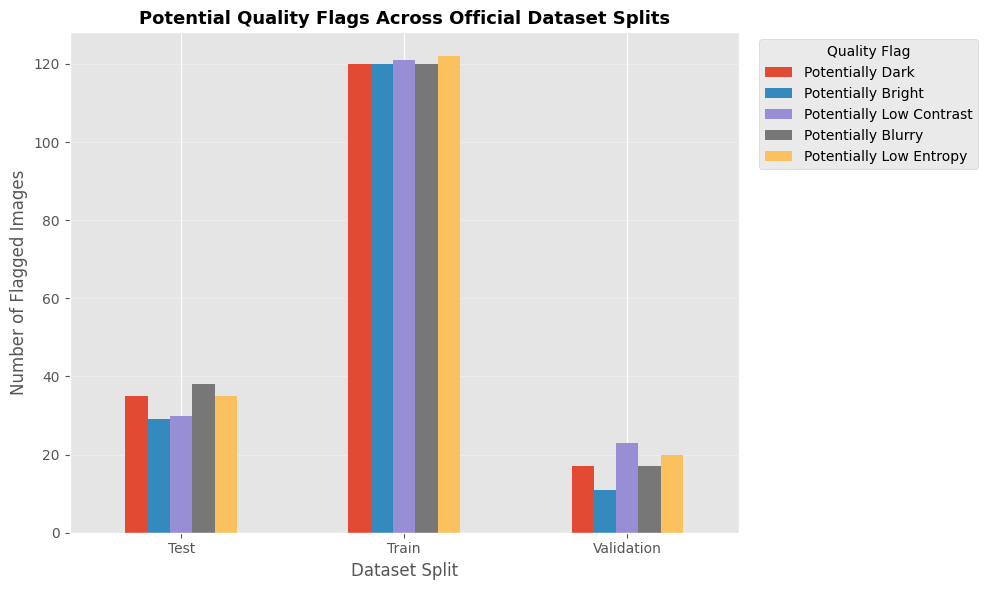

In [20]:
# ============================================================
# 12A. Visualization of Potential Quality Flags
# ============================================================

plot_df = quality_summary_df.set_index("Split")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title(
    "Potential Quality Flags Across Official Dataset Splits",
    fontsize=13,
    weight="bold",
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Flagged Images")

plt.xticks(rotation=0)

plt.legend(
    title="Quality Flag",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "quality_flag_summary.png",
    dpi=300,
)

plt.show()

### Interpretation

- Only a small proportion of images fall into the extreme ends of the
  training-set quality distributions.

- These samples are flagged as **potential quality outliers** and
  require visual inspection before any decision regarding removal.

- The official MedMNIST dataset splits remain unchanged throughout
  Task 1 to ensure fair benchmarking and reproducibility.

# 13. Visual Inspection of Potential Quality Outliers

Automated quality metrics may flag images that appear unusually dark,
bright, blurry, low contrast, or information-poor.

These samples are **visually inspected only**.

No images are removed during Task 1.

This inspection is intended to verify whether automatically flagged
samples genuinely appear different from typical BloodMNIST images.

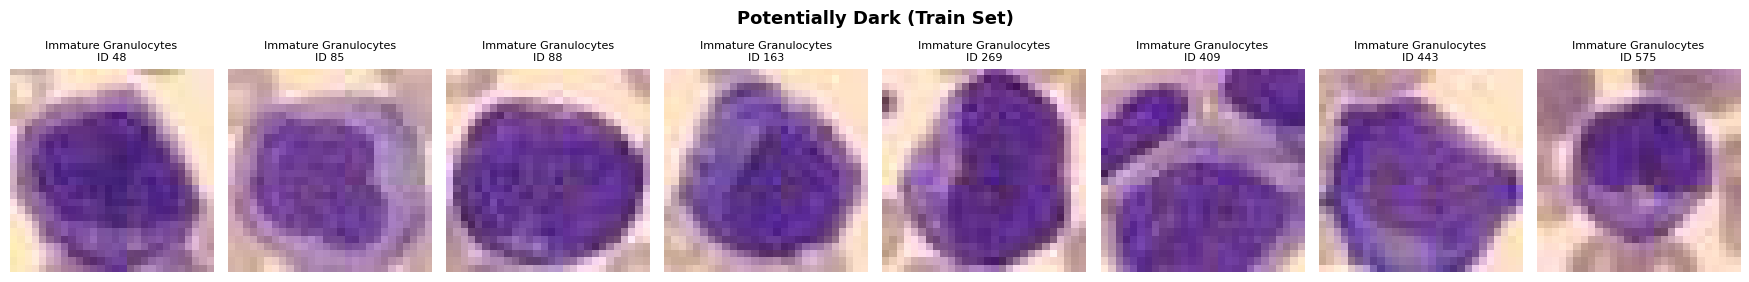

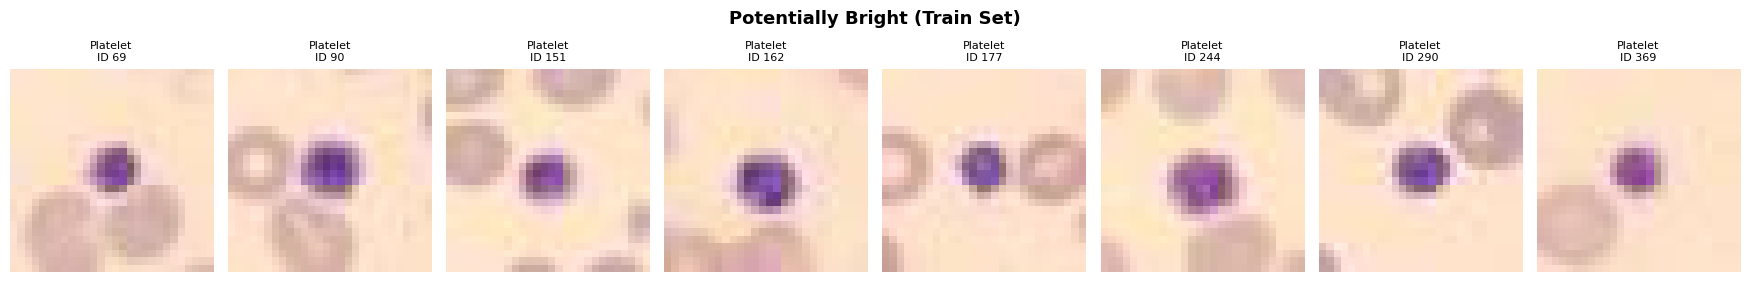

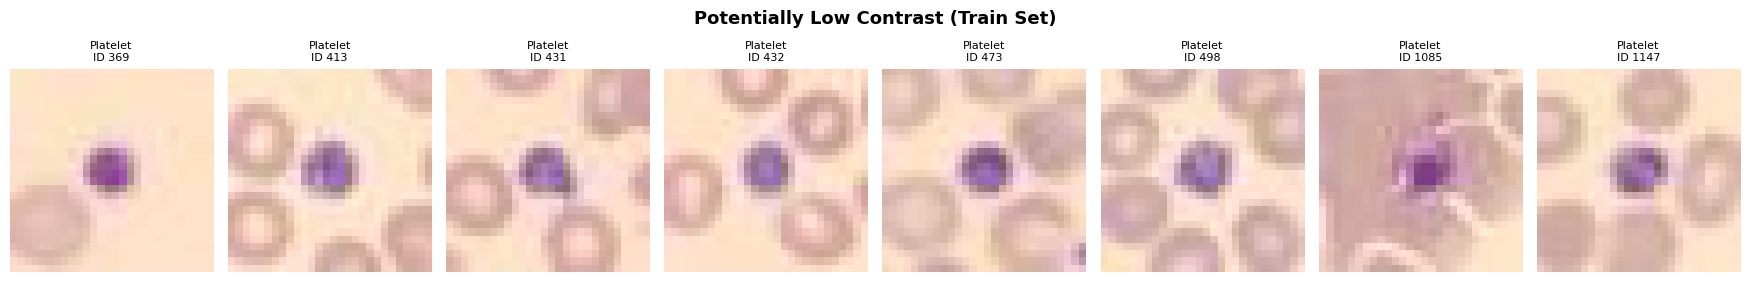

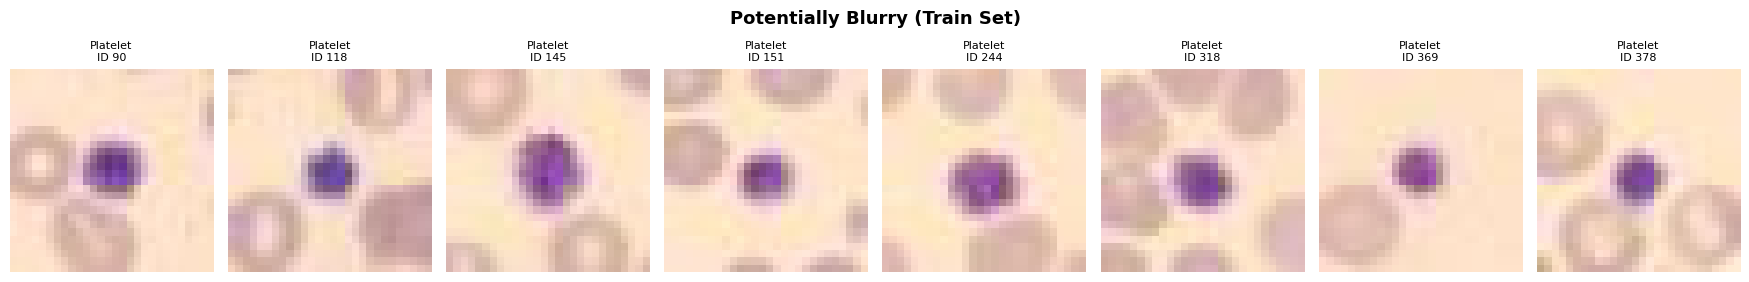

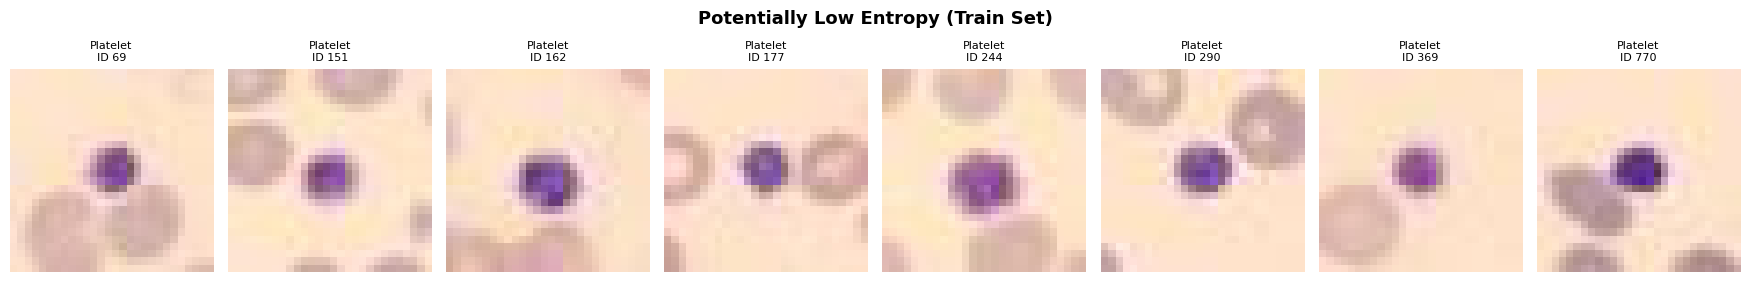

In [21]:
# ============================================================
# 13. Visual Inspection of Potential Quality Outliers
# ============================================================

def show_flagged_examples(
    dataframe,
    images,
    flag_column,
    split="Train",
    number_to_show=8,
):
    """
    Display images flagged by a quality criterion.
    """

    subset = dataframe[
        (dataframe["Split"] == split)
        &
        (dataframe[flag_column])
    ].head(number_to_show)

    if len(subset) == 0:
        print(f"No images flagged for {flag_column}")
        return

    fig, axes = plt.subplots(
        1,
        len(subset),
        figsize=(2.2 * len(subset), 3)
    )

    if len(subset) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):

        idx = int(row["Image Index"])

        ax.imshow(images[idx])

        ax.set_title(
            f"{row['Class']}\nID {idx}",
            fontsize=8
        )

        ax.axis("off")

    plt.suptitle(
        f"{flag_column} ({split} Set)",
        fontsize=13,
        weight="bold",
    )

    plt.tight_layout()

    plt.show()

show_flagged_examples(
    image_metrics_df,
    train_images,
    "Potentially Dark"
)

show_flagged_examples(
    image_metrics_df,
    train_images,
    "Potentially Bright"
)

show_flagged_examples(
    image_metrics_df,
    train_images,
    "Potentially Low Contrast"
)

show_flagged_examples(
    image_metrics_df,
    train_images,
    "Potentially Blurry"
)

show_flagged_examples(
    image_metrics_df,
    train_images,
    "Potentially Low Entropy"
)

### Interpretation

The automatically flagged samples should be regarded only as
**potential quality outliers**.

Visual inspection confirms whether the images truly appear darker,
brighter, blurrier, or less informative than typical BloodMNIST
samples.

Following the MedMNIST benchmark protocol, no samples are removed or
modified during Task 1.

# 14. Exact Duplicate Detection and Cross-Split Leakage Audit

### Objective

This section audits the BloodMNIST dataset for **exact duplicate images** using SHA-256 hashing.

The analysis reports:

- Within-split duplicate images
- Cross-split duplicate groups
- Potential data leakage between official splits

---

### Important Project Policy

Following the MedMNIST benchmark protocol:

- Exact duplicates are **reported but NOT removed** in Task 1.
- The official Train / Validation / Test splits are preserved.
- If duplicate-cleaning is performed, it will be reported separately as a sensitivity experiment in Task 2 or Task 3.
- No graph is constructed by combining multiple dataset splits.

This ensures fair comparison with published BloodMNIST benchmark results.

In [22]:
# ============================================================
# 14. Exact Duplicate Detection and Cross-Split Leakage Audit
# ============================================================

def image_hash(image):
    """Return SHA-256 hash of an image."""
    return hashlib.sha256(
        np.ascontiguousarray(image).tobytes()
    ).hexdigest()


# ------------------------------------------------------------
# Compute image hashes
# ------------------------------------------------------------

hash_records = []

for split_name, (images, labels) in SPLITS.items():

    print(f"Hashing {split_name} images...")

    for image_index, (image, label) in enumerate(zip(images, labels)):

        hash_records.append({
            "Hash": image_hash(image),
            "Split": split_name,
            "Image Index": image_index,
            "Label ID": int(label),
            "Class": LABEL_MAP[int(label)],
        })

hash_df = pd.DataFrame(hash_records)


# ------------------------------------------------------------
# Within-split duplicate summary
# ------------------------------------------------------------

within_split_summary = []

for split_name, (images, _) in SPLITS.items():

    subset = hash_df[hash_df["Split"] == split_name]

    duplicate_images = int(
        subset.duplicated("Hash", keep="first").sum()
    )

    duplicate_groups = int(
        subset.loc[
            subset.duplicated("Hash", keep=False),
            "Hash"
        ].nunique()
    )

    unique_images = int(subset["Hash"].nunique())

    duplicate_percentage = (
        duplicate_images / len(images)
    ) * 100

    within_split_summary.append({

        "Split": split_name,

        "Total Images": len(images),

        "Unique Images": unique_images,

        "Extra Duplicate Images": duplicate_images,

        "Duplicate Groups": duplicate_groups,

        "Duplicate %": round(
            duplicate_percentage,
            3,
        ),
    })

within_split_duplicate_df = pd.DataFrame(
    within_split_summary
)

print("\nWithin-Split Duplicate Summary")
display(within_split_duplicate_df)


# ------------------------------------------------------------
# Cross-split duplicate analysis
# ------------------------------------------------------------

cross_split_groups = (
    hash_df
    .groupby("Hash")
    .filter(lambda g: g["Split"].nunique() > 1)
)

if cross_split_groups.empty:

    cross_split_summary_df = pd.DataFrame(
        columns=[
            "Hash",
            "Occurrences",
            "Splits",
            "Classes",
            "Label Consistent",
            "Leakage Risk",
        ]
    )

else:

    cross_split_summary_df = (
        cross_split_groups
        .groupby("Hash")
        .agg(
            Occurrences=("Hash", "size"),
            Splits=("Split",
                    lambda x: ", ".join(sorted(set(x)))),
            Classes=("Class",
                     lambda x: ", ".join(sorted(set(x)))),
            **{
                "Label Consistent":
                (
                    "Label ID",
                    lambda x: len(set(x)) == 1
                )
            }
        )
        .reset_index()
    )

    cross_split_summary_df["Leakage Risk"] = np.where(
        cross_split_summary_df["Label Consistent"],
        "Potential Leakage",
        "Label Conflict"
    )


print("\nCross-Split Duplicate Groups")
display(cross_split_summary_df)

print(
    f"\nNumber of Cross-Split Duplicate Groups: "
    f"{len(cross_split_summary_df)}"
)


# ------------------------------------------------------------
# Overall duplicate audit summary
# ------------------------------------------------------------

total_duplicate_images = int(
    within_split_duplicate_df[
        "Extra Duplicate Images"
    ].sum()
)

if len(cross_split_summary_df) == 0:

    leakage_status = "No Cross-Split Leakage Detected"

elif len(cross_split_summary_df) < 10:

    leakage_status = "Low"

elif len(cross_split_summary_df) < 50:

    leakage_status = "Moderate"

else:

    leakage_status = "High"


audit_summary_df = pd.DataFrame({

    "Metric":[
        "Within-Split Duplicate Images",
        "Cross-Split Duplicate Groups",
        "Leakage Risk",
        "Official Split Preserved",
        "Duplicates Removed in Task 1"
    ],

    "Value":[
        total_duplicate_images,
        len(cross_split_summary_df),
        leakage_status,
        "Yes",
        "No"
    ]

})

print("\nDuplicate Audit Summary")
display(audit_summary_df)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

within_split_duplicate_df.to_csv(
    TABLE_DIR /
    "within_split_duplicate_summary.csv",
    index=False,
)

cross_split_summary_df.to_csv(
    TABLE_DIR /
    "cross_split_duplicate_groups.csv",
    index=False,
)

audit_summary_df.to_csv(
    TABLE_DIR /
    "duplicate_audit_summary.csv",
    index=False,
)

print("\nDuplicate audit completed successfully.")

Hashing Train images...
Hashing Validation images...
Hashing Test images...

Within-Split Duplicate Summary


,Split,Total Images,Unique Images,Extra Duplicate Images,Duplicate Groups,Duplicate %
0,Train,11959,11951,8,8,0.067
1,Validation,1712,1712,0,0,0.000
2,Test,3421,3421,0,0,0.000



Cross-Split Duplicate Groups


,Hash,Occurrences,Splits,Classes,Label Consistent,Leakage Risk
0,04c46b18e78dd05152cbdbd3a6216915b254fe8e3295e4...,2,"Test, Validation",Eosinophil,True,Potential Leakage
1,2e1357eaa909eed4d6cfacf5f6c0b32e8836e4aca62a87...,2,"Test, Train","Eosinophil, Neutrophil",False,Label Conflict
2,4f9c9fea816a7864d5fb9b94bfe8e81930b2678620002d...,2,"Test, Train",Eosinophil,True,Potential Leakage
3,96b8d45879d3c142ba5992729fadf12ea2a3505120e08f...,2,"Train, Validation",Eosinophil,True,Potential Leakage
4,a7b330090d9bbe1a92974e3312a370f3a4f88bcf91fc6d...,2,"Test, Train",Basophil,True,Potential Leakage
5,a960b856e21f81c76495535186edbc147535519e55681b...,2,"Train, Validation",Basophil,True,Potential Leakage
6,ab8f2e7af9cbf8bb7c27a90a31f16b05ff0015ad7e536a...,2,"Test, Train",Basophil,True,Potential Leakage
7,ae83c90763591abd564c87c5e9ad8bbc8b7849b9389e2e...,2,"Train, Validation",Eosinophil,True,Potential Leakage
8,ce33176f168412e7c1c1600c08de0db62016ceca964ca5...,2,"Test, Train",Basophil,True,Potential Leakage



Number of Cross-Split Duplicate Groups: 9

Duplicate Audit Summary


,Metric,Value
0,Within-Split Duplicate Images,8
1,Cross-Split Duplicate Groups,9
2,Leakage Risk,Low
3,Official Split Preserved,Yes
4,Duplicates Removed in Task 1,No



Duplicate audit completed successfully.


# 15. Split Distribution Comparison

## Objective

The official BloodMNIST dataset provides predefined Training, Validation, and Test splits.

This section compares image-quality and colour statistics across the three official splits to verify that they follow similar data distributions.

A similar distribution across splits indicates that the official partitioning is consistent and suitable for fair model evaluation.

> **Note:** This analysis is descriptive only. The official dataset splits are preserved without modification.

Split-wise Image Statistics


Brightness                       Contrast                   Blur Score                    Entropy               Edge Strength                 \
                  mean     std      median       mean    std     median       mean      std    median    mean    std median          mean    std  median   
Split                                                                                                                                                      
Test        179.468994  15.380  178.514999  52.421001  9.929  54.480000   1529.404  557.766  1570.930   6.582  0.429  6.679        13.028  2.193  13.375   
Train       179.544006  15.439  178.395004  52.352001  9.904  54.566002   1518.534  550.999  1554.902   6.577  0.434  6.676        12.984  2.226  13.347   
Validation  179.585007  14.989  178.535995  52.210999  9.802  54.473999   1530.340  558.036  1562.878   6.591  0.424  6.687        13.053  2.233  13.418   

              Red Mean                      Green Mean                          Blue Mean                     
                  mean     std      median        mean        std      median        mean    std      median  
Split                                                                                                         
Test        202.485001  15.454  201.968994  168.130997  17.473000  166.897003  177.481995  7.460  176.653000  
Train       202.559006  15.453  201.936005  168.212997  17.549999  166.835007  177.529007  7.473  176.537003  
Validation  202.572006  15.090  202.026993  168.268997  17.046000  167.100006  177.563995  7.346  176.580002

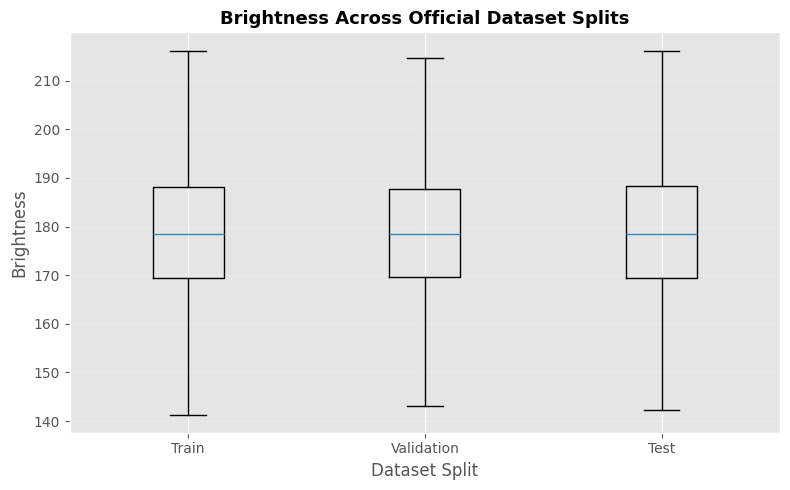

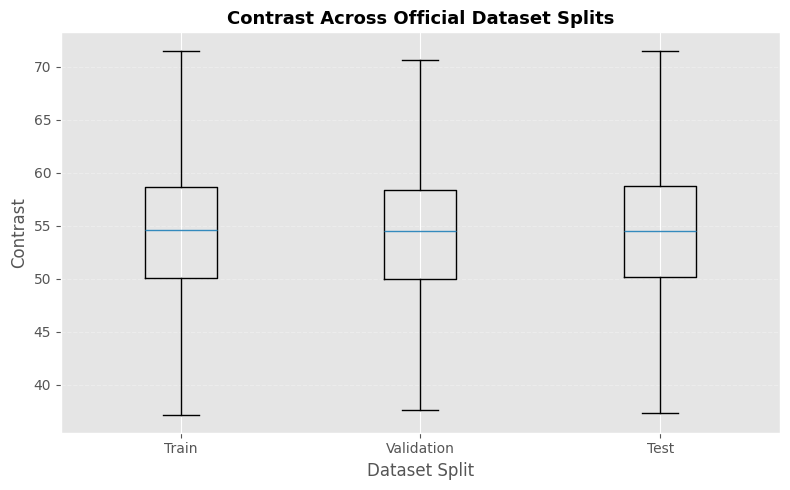

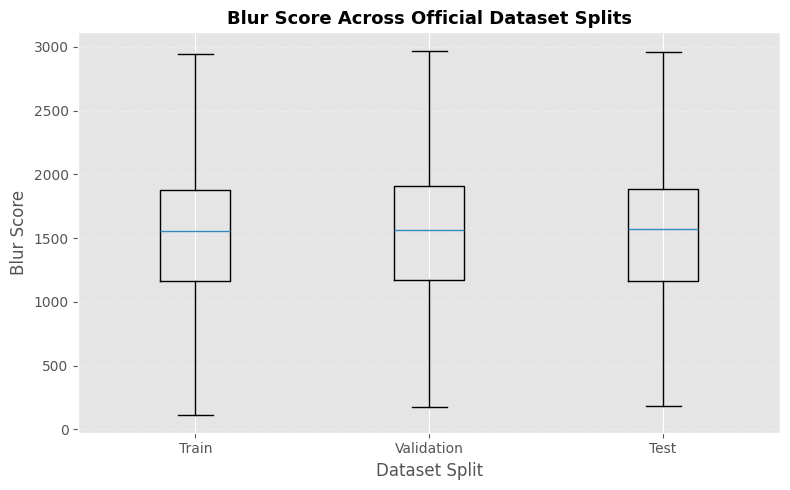

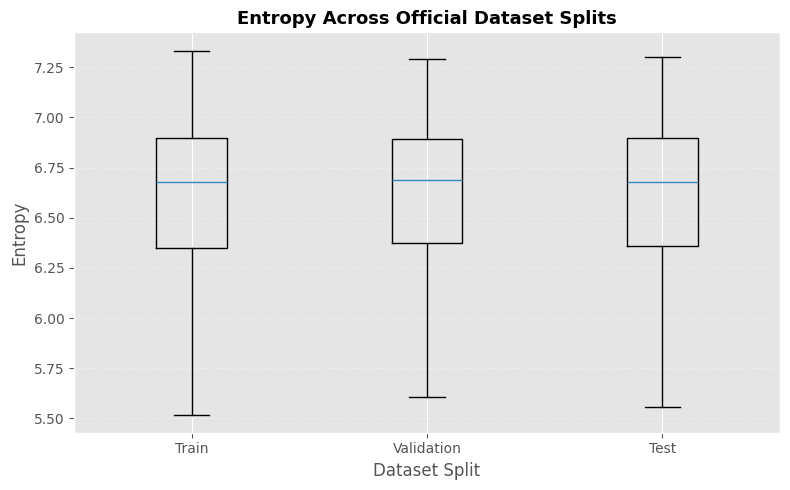

In [23]:
# ============================================================
# 15. Split Distribution Comparison
# ============================================================

metrics = [
    "Brightness",
    "Contrast",
    "Blur Score",
    "Entropy",
    "Edge Strength",
    "Red Mean",
    "Green Mean",
    "Blue Mean",
]

split_metric_summary_df = (
    image_metrics_df
    .groupby("Split")[metrics]
    .agg(["mean", "std", "median"])
    .round(3)
)

print("Split-wise Image Statistics")
display(split_metric_summary_df)

split_metric_summary_df.to_csv(
    TABLE_DIR / "split_metric_summary.csv"
)

# ------------------------------------------------------------
# Boxplots for major image-quality metrics
# ------------------------------------------------------------

for metric_name in [

    "Brightness",
    "Contrast",
    "Blur Score",
    "Entropy",

]:

    ordered_data = [

        image_metrics_df.loc[
            image_metrics_df["Split"] == split_name,
            metric_name,
        ].values

        for split_name in SPLITS.keys()

    ]

    plt.figure(figsize=(8,5))

    plt.boxplot(
        ordered_data,
        labels=list(SPLITS.keys()),
        showfliers=False,
    )

    plt.title(
        f"{metric_name} Across Official Dataset Splits",
        fontsize=13,
        weight="bold",
    )

    plt.xlabel("Dataset Split")
    plt.ylabel(metric_name)

    plt.grid(
        axis="y",
        alpha=0.3,
        linestyle="--",
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"split_{metric_name.lower().replace(' ','_')}.png",
        dpi=300,
    )

    plt.show()

### Interpretation

- The distributions of brightness, contrast, blur, and entropy are broadly similar across the official Training, Validation, and Test splits.
- No substantial distribution shift is observed, suggesting that the official MedMNIST partitioning is consistent.
- Therefore, the predefined dataset splits are retained for all subsequent experiments.

# 16. Class Prototype Similarity

## Objective

Each blood-cell class is represented by its **mean (prototype) image** computed from the training set.

Cosine similarity is then calculated between every pair of class prototypes.

A high similarity indicates that two classes share similar global appearance, suggesting that **global colour information alone may not be sufficient for discrimination**. This motivates the use of local feature extraction, attention mechanisms, and graph-based relational learning in the proposed CNN–Attention–GCN architecture.

> **Note:** This analysis is descriptive only and does not measure classification performance.

Prototype Similarity Matrix


,Basophil,Eosinophil,Erythroblast,Immature Granulocytes,Lymphocyte,Monocyte,Neutrophil,Platelet
Basophil,1.0000,0.9977,0.9892,0.9988,0.9919,0.9970,0.9967,0.9691
Eosinophil,0.9977,1.0000,0.9891,0.9987,0.9886,0.9983,0.9979,0.9762
Erythroblast,0.9892,0.9891,1.0000,0.9903,0.9976,0.9876,0.9956,0.9906
Immature Granulocytes,0.9988,0.9987,0.9903,1.0000,0.9908,0.9992,0.9976,0.9743
Lymphocyte,0.9919,0.9886,0.9976,0.9908,1.0000,0.9874,0.9951,0.9801
Monocyte,0.9970,0.9983,0.9876,0.9992,0.9874,1.0000,0.9961,0.9736
Neutrophil,0.9967,0.9979,0.9956,0.9976,0.9951,0.9961,1.0000,0.9840
Platelet,0.9691,0.9762,0.9906,0.9743,0.9801,0.9736,0.9840,1.0000


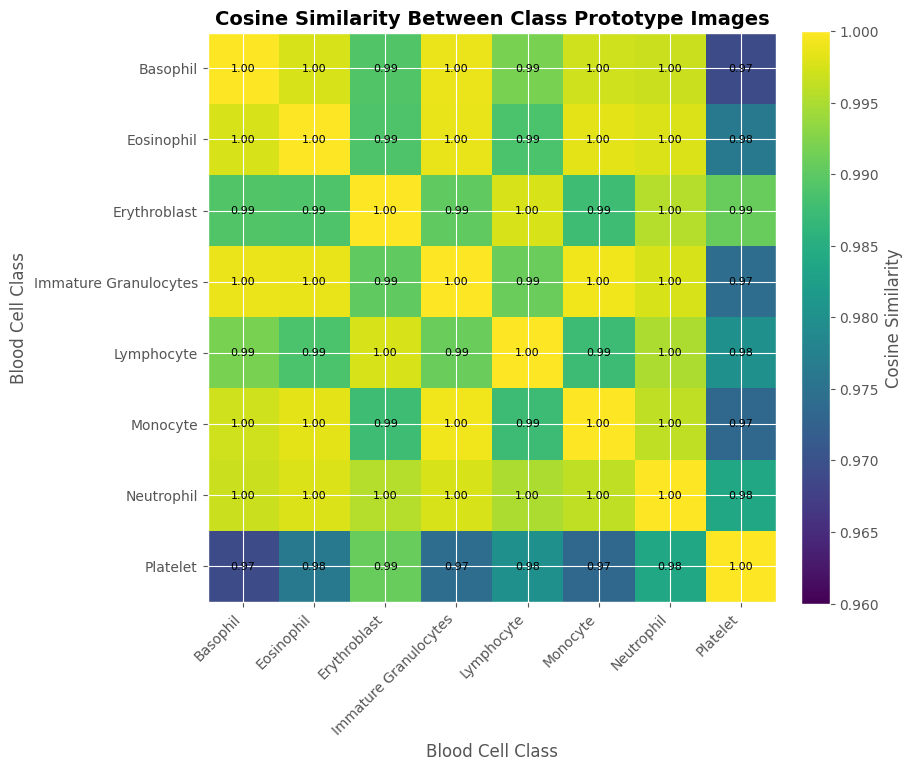

Prototype Similarity Summary


,Metric,Value
0,Average Off-Diagonal Similarity,0.9903
1,Maximum Off-Diagonal Similarity,0.9992
2,Minimum Off-Diagonal Similarity,0.9691


In [24]:
# ============================================================
# 16. Class Prototype Similarity
# ============================================================

# Create prototype matrix
prototype_matrix = np.stack([
    class_mean_images[label_id].reshape(-1)
    for label_id in LABEL_MAP
])

# Cosine similarity
prototype_similarity = cosine_similarity(prototype_matrix)

prototype_similarity_df = pd.DataFrame(
    prototype_similarity,
    index=list(LABEL_MAP.values()),
    columns=list(LABEL_MAP.values()),
)

print("Prototype Similarity Matrix")
display(prototype_similarity_df.round(4))

prototype_similarity_df.to_csv(
    TABLE_DIR / "class_prototype_similarity.csv"
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9,8))

im = plt.imshow(
    prototype_similarity,
    cmap="viridis",
    vmin=0.96,
    vmax=1.00,
)

plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04,
    label="Cosine Similarity"
)

plt.title(
    "Cosine Similarity Between Class Prototype Images",
    fontsize=14,
    weight="bold",
)

plt.xlabel("Blood Cell Class")
plt.ylabel("Blood Cell Class")

plt.xticks(
    range(len(LABEL_MAP)),
    list(LABEL_MAP.values()),
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(LABEL_MAP)),
    list(LABEL_MAP.values()),
)

for i in range(len(LABEL_MAP)):
    for j in range(len(LABEL_MAP)):

        value = prototype_similarity[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value < 0.60 else "black",
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_prototype_similarity.png",
    dpi=300,
)

plt.show()

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

similarity_without_diagonal = prototype_similarity[
    ~np.eye(len(LABEL_MAP), dtype=bool)
]

prototype_summary_df = pd.DataFrame({

    "Metric":[
        "Average Off-Diagonal Similarity",
        "Maximum Off-Diagonal Similarity",
        "Minimum Off-Diagonal Similarity",
    ],

    "Value":[
        round(similarity_without_diagonal.mean(),4),
        round(similarity_without_diagonal.max(),4),
        round(similarity_without_diagonal.min(),4),
    ]

})

print("Prototype Similarity Summary")
display(prototype_summary_df)

prototype_summary_df.to_csv(
    TABLE_DIR / "prototype_similarity_summary.csv",
    index=False,
)

### Interpretation

- As expected, each class prototype has a cosine similarity of **1.00** with itself.
- The average off-diagonal similarity is **0.9903**, indicating that many blood-cell classes share very similar global visual characteristics.
- The most similar pair is **Basophil ↔ Monocyte** (0.9992), while the least similar pair is **Basophil ↔ Platelet** (0.9691).
- Because most class prototypes are highly similar, global appearance alone is unlikely to provide sufficient discrimination.
- These observations support the proposed CNN–Attention–GCN architecture, where CNN extracts local features, the attention module emphasizes discriminative regions, and the GCN models spatial relationships between image regions.

# 17. Interactive Data Exploration (Optional)

## Objective

Interactive visualizations are provided for exploratory purposes.

These plots allow users to zoom, pan, filter, and inspect individual samples interactively within the Kaggle notebook.

> **Note:** These figures are supplementary only. All analyses presented in previous sections are based on the static publication-quality figures generated using Matplotlib.

In [25]:
# ============================================================
# 17. Interactive Data Exploration (Optional)
# ============================================================

try:

    import plotly.express as px

    # --------------------------------------------------------
    # Interactive Class Distribution
    # --------------------------------------------------------

    fig = px.bar(

        class_distribution_df,

        x="Class",

        y="Count",

        color="Split",

        barmode="group",

        hover_data=[

            "Label ID",
            "Percentage",

        ],

        title="Interactive BloodMNIST Class Distribution"

    )

    fig.update_layout(

        xaxis_title="Blood Cell Class",

        yaxis_title="Number of Images",

        template="plotly_white",

    )

    fig.show()

    # --------------------------------------------------------
    # Interactive Image Quality
    # --------------------------------------------------------

    fig = px.scatter(

        image_metrics_df,

        x="Brightness",

        y="Contrast",

        color="Class",

        symbol="Split",

        hover_data=[

            "Image Index",
            "Label ID",
            "Blur Score",
            "Entropy",
            "Edge Strength",

        ],

        title="Brightness vs Contrast"

    )

    fig.update_layout(

        template="plotly_white",

        xaxis_title="Brightness",

        yaxis_title="Contrast",

    )

    fig.show()

except ImportError:

    print("Plotly is not installed.")

# 18. Principal Component Analysis (PCA)

## Objective

Principal Component Analysis (PCA) is performed to visualize the global appearance of BloodMNIST images in a two-dimensional feature space.

A fixed stratified subset of the training set is used to ensure that every blood-cell class is represented equally while keeping the visualization computationally efficient.

The purpose of this analysis is purely exploratory. It helps assess whether different blood-cell classes exhibit natural visual separation before any deep learning model is trained.

> **Note:** PCA is performed directly on normalized raw RGB pixel values and should not be interpreted as model performance.

In [26]:
# ============================================================
# 18. Principal Component Analysis (PCA)
# ============================================================

# ------------------------------------------------------------
# Stratified sampling for PCA
# ------------------------------------------------------------

samples_per_class = 200

selected_indices = []

for label_id in LABEL_MAP:

    candidate_indices = np.where(
        train_labels == label_id
    )[0]

    sample_size = min(
        samples_per_class,
        len(candidate_indices),
    )

    chosen = rng.choice(
        candidate_indices,
        size=sample_size,
        replace=False,
    )

    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)


# ------------------------------------------------------------
# Prepare normalized image vectors
# ------------------------------------------------------------

pca_images = (
    train_images[selected_indices]
    .astype(np.float32)
    .reshape(len(selected_indices), -1)
    / 255.0
)

pca_labels = train_labels[selected_indices]


# ------------------------------------------------------------
# Perform PCA
# ------------------------------------------------------------

pca_model = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

pca_coordinates = pca_model.fit_transform(
    pca_images
)


# ------------------------------------------------------------
# PCA dataframe
# ------------------------------------------------------------

pca_df = pd.DataFrame({

    "PC1": pca_coordinates[:, 0],

    "PC2": pca_coordinates[:, 1],

    "Label ID": pca_labels.astype(int),

    "Class": [
        LABEL_MAP[int(label)]
        for label in pca_labels
    ],

    "Training Index": selected_indices,

})


# ------------------------------------------------------------
# Explained variance
# ------------------------------------------------------------

explained_variance_df = pd.DataFrame({

    "Principal Component": [
        "PC1",
        "PC2",
        "Total",
    ],

    "Explained Variance (%)": [

        round(
            pca_model.explained_variance_ratio_[0] * 100,
            2,
        ),

        round(
            pca_model.explained_variance_ratio_[1] * 100,
            2,
        ),

        round(
            pca_model.explained_variance_ratio_.sum() * 100,
            2,
        ),

    ],

})


print("PCA Explained Variance")
display(explained_variance_df)

print("\nFirst Five PCA Coordinates")
display(pca_df.head())


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

explained_variance_df.to_csv(
    TABLE_DIR / "pca_explained_variance.csv",
    index=False,
)

pca_df.to_csv(
    TABLE_DIR / "pca_coordinates.csv",
    index=False,
)

print(
    f"\nTotal samples used for PCA: {len(pca_df)}"
)

PCA Explained Variance


,Principal Component,Explained Variance (%)
0,PC1,27.450001
1,PC2,10.330000
2,Total,37.779999



First Five PCA Coordinates


,PC1,PC2,Label ID,Class,Training Index
0,-2.906783,-1.561152,0,Basophil,7128
1,-1.002656,-1.300834,0,Basophil,7423
2,-0.076030,-3.845661,0,Basophil,7072
3,-4.418967,-0.317261,0,Basophil,10522
4,-2.291916,-1.212551,0,Basophil,9965



Total samples used for PCA: 1600


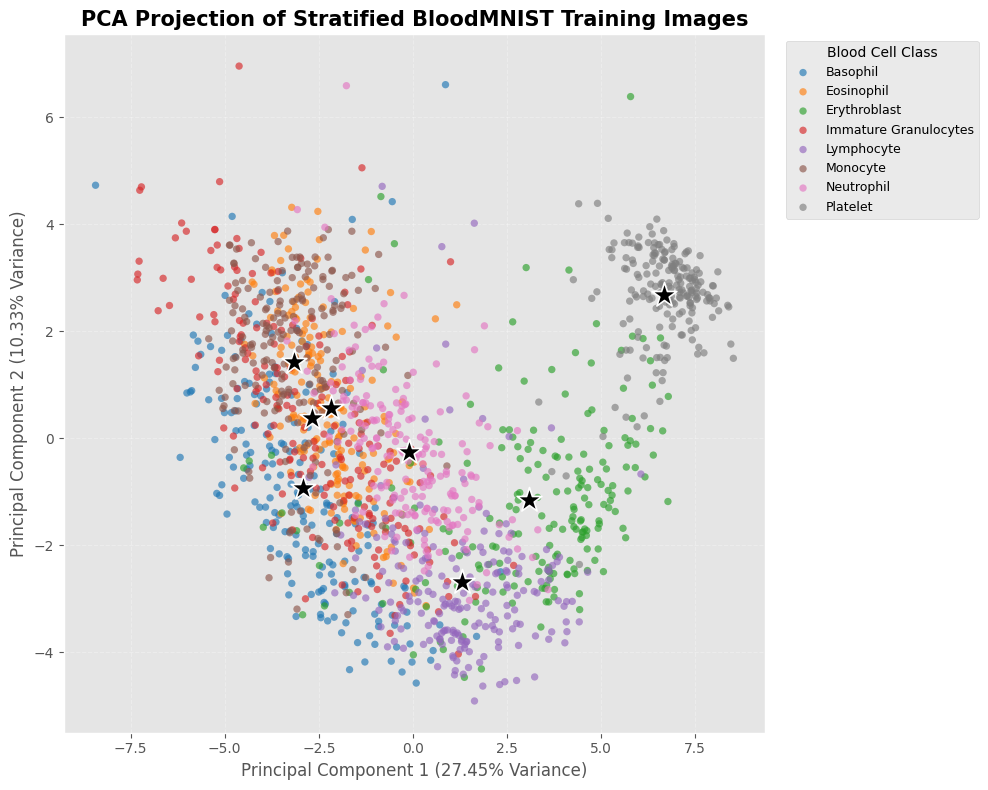

In [27]:
# ============================================================
# 18A. PCA Visualization
# ============================================================

plt.figure(figsize=(10, 8))

colors = plt.cm.tab10.colors

# ------------------------------------------------------------
# Plot each class separately
# ------------------------------------------------------------

for color, class_name in zip(colors, LABEL_MAP.values()):

    subset = pca_df[
        pca_df["Class"] == class_name
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=28,
        alpha=0.65,
        color=color,
        label=class_name,
        edgecolors="none",
    )

# ------------------------------------------------------------
# Plot class centroids
# ------------------------------------------------------------

centroids = (
    pca_df
    .groupby("Class")[["PC1", "PC2"]]
    .mean()
)

for class_name in LABEL_MAP.values():

    x = centroids.loc[class_name, "PC1"]
    y = centroids.loc[class_name, "PC2"]

    plt.scatter(
        x,
        y,
        marker="*",
        s=350,
        color="black",
        edgecolors="white",
        linewidth=1.2,
        zorder=5,
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

pc1_var = pca_model.explained_variance_ratio_[0] * 100
pc2_var = pca_model.explained_variance_ratio_[1] * 100

plt.xlabel(
    f"Principal Component 1 ({pc1_var:.2f}% Variance)",
    fontsize=12,
)

plt.ylabel(
    f"Principal Component 2 ({pc2_var:.2f}% Variance)",
    fontsize=12,
)

plt.title(
    "PCA Projection of Stratified BloodMNIST Training Images",
    fontsize=15,
    weight="bold",
)

plt.grid(
    alpha=0.30,
    linestyle="--",
)

plt.legend(
    title="Blood Cell Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "pca_projection.png",
    dpi=300,
)

plt.show()

In [28]:
# ============================================================
# 18B. PCA Summary
# ============================================================

class_center_df = (
    pca_df
    .groupby("Class")[["PC1", "PC2"]]
    .mean()
    .round(3)
)

print("Class Centroids in PCA Space")

display(class_center_df)

class_center_df.to_csv(
    TABLE_DIR /
    "pca_class_centroids.csv"
)

Class Centroids in PCA Space


,PC1,PC2
Class,,
Basophil,-2.916,-0.939
Eosinophil,-2.184,0.558
Erythroblast,3.090,-1.161
Immature Granulocytes,-2.694,0.384
Lymphocyte,1.294,-2.680
Monocyte,-3.166,1.432
Neutrophil,-0.105,-0.262
Platelet,6.681,2.668


### Interpretation

- The first two principal components summarize the largest variance present in the normalized RGB images.
- Several blood-cell classes exhibit noticeable overlap, indicating that raw pixel appearance alone is insufficient for perfect discrimination.
- The class centroids are separated but remain relatively close in the PCA space, suggesting that many blood-cell types share similar global visual characteristics.
- These findings support the use of deep feature extraction (CNN), attention mechanisms, and graph neural networks instead of relying solely on global image appearance.

# 19. Graph Readiness Preview

## Objective

The proposed model converts CNN feature maps into graphs before Graph Convolutional Network (GCN) processing.

Since BloodMNIST images are **28×28 RGB**, applying two successive **2×2 pooling operations** naturally produces a **7×7 feature map**.

Each spatial location in this feature map can be interpreted as a graph node.

This cell demonstrates that concept by dividing the original image into **49 equal patches (7×7)**.

> **Note:** This is only an EDA visualization. No graph is used for model training in this notebook.

Graph Configuration


,Graph Property,Value
0,Image Resolution,28 × 28
1,Patch Size,4 × 4
2,Grid Size,7 × 7
3,Nodes per Image,49
4,Neighbour Type,4-Neighbour
5,Undirected Edges,84
6,Directed Edges,168
7,Graph Ready,Yes


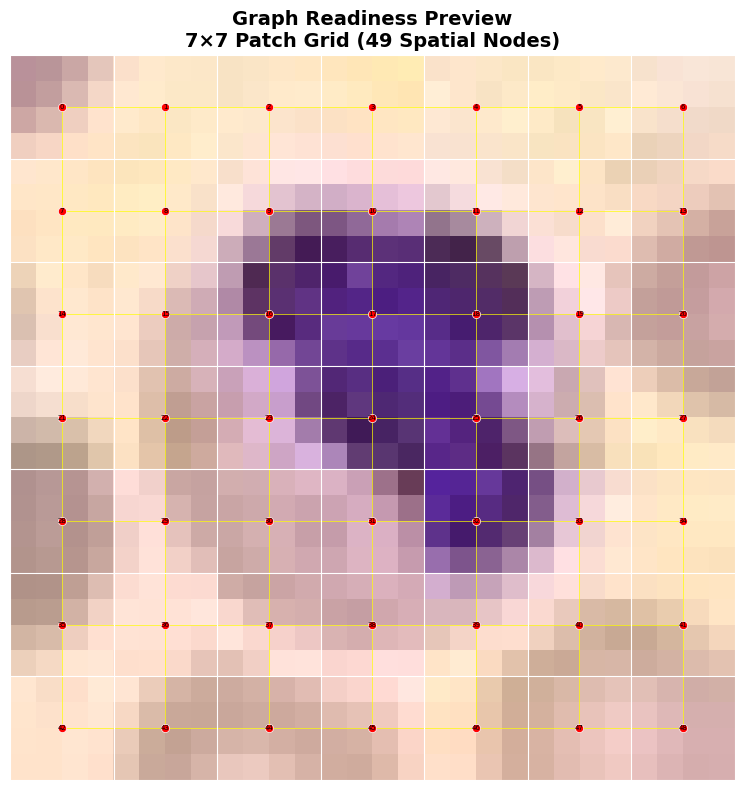

Total Nodes : 49
Total Undirected Edges : 84
Total Directed Edges : 168


In [29]:
# ============================================================
# 19. Graph Readiness Preview (7×7 Patch Graph)
# ============================================================

PATCH_SIZE = 4
GRID_SIZE = 28 // PATCH_SIZE
NUM_NODES = GRID_SIZE * GRID_SIZE


# ------------------------------------------------------------
# Build spatial graph (4-neighbour)
# ------------------------------------------------------------

def build_grid_edges(grid_size):

    edges = []

    for row in range(grid_size):

        for col in range(grid_size):

            node = row * grid_size + col

            # Right neighbour
            if col + 1 < grid_size:
                right = row * grid_size + (col + 1)
                edges.append((node, right))

            # Bottom neighbour
            if row + 1 < grid_size:
                bottom = (row + 1) * grid_size + col
                edges.append((node, bottom))

    return edges


grid_edges = build_grid_edges(GRID_SIZE)


# ------------------------------------------------------------
# Graph configuration table
# ------------------------------------------------------------

graph_configuration_df = pd.DataFrame({

    "Graph Property":[
        "Image Resolution",
        "Patch Size",
        "Grid Size",
        "Nodes per Image",
        "Neighbour Type",
        "Undirected Edges",
        "Directed Edges",
        "Graph Ready"
    ],

    "Value":[
        "28 × 28",
        "4 × 4",
        f"{GRID_SIZE} × {GRID_SIZE}",
        NUM_NODES,
        "4-Neighbour",
        len(grid_edges),
        len(grid_edges)*2,
        "Yes"
    ]

})

print("Graph Configuration")

display(graph_configuration_df)

graph_configuration_df.to_csv(
    TABLE_DIR/"graph_configuration.csv",
    index=False
)


# ------------------------------------------------------------
# Select one sample image
# ------------------------------------------------------------

selected_label = 6      # Neutrophil

selected_index = np.where(
    train_labels == selected_label
)[0][0]

sample_image = train_images[selected_index]


# ------------------------------------------------------------
# Draw graph preview
# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.imshow(sample_image)

# draw grid

for position in range(0,29,PATCH_SIZE):

    plt.axhline(
        position-0.5,
        color="white",
        linewidth=0.8,
    )

    plt.axvline(
        position-0.5,
        color="white",
        linewidth=0.8,
    )


centers = np.arange(
    PATCH_SIZE/2 - 0.5,
    28,
    PATCH_SIZE,
)

node_locations = {}

node_id = 0

for row,y in enumerate(centers):

    for col,x in enumerate(centers):

        node_locations[node_id]=(x,y)

        node_id+=1


# ------------------------------------------------------------
# Draw edges
# ------------------------------------------------------------

for start,end in grid_edges:

    x1,y1=node_locations[start]

    x2,y2=node_locations[end]

    plt.plot(
        [x1,x2],
        [y1,y2],
        color="yellow",
        linewidth=0.6,
        alpha=0.8,
        zorder=1,
    )


# ------------------------------------------------------------
# Draw nodes
# ------------------------------------------------------------

for node,(x,y) in node_locations.items():

    plt.scatter(
        x,
        y,
        s=35,
        color="red",
        edgecolors="white",
        linewidth=0.5,
        zorder=3,
    )

    plt.text(
        x,
        y,
        str(node),
        fontsize=5,
        color="black",
        ha="center",
        va="center",
        zorder=4,
    )


plt.title(
    "Graph Readiness Preview\n"
    "7×7 Patch Grid (49 Spatial Nodes)",
    fontsize=14,
    weight="bold",
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"graph_readiness_preview.png",
    dpi=300,
)

plt.show()


print(f"Total Nodes : {NUM_NODES}")
print(f"Total Undirected Edges : {len(grid_edges)}")
print(f"Total Directed Edges : {len(grid_edges)*2}")

# 19A. Graph Statistics and Suitability Analysis

## Objective

This section summarizes the structural properties of the graph that will be constructed from BloodMNIST images.

The analysis reports graph connectivity, node degree, graph density, and overall suitability for Graph Convolutional Networks (GCNs).

> **Note:** These statistics describe the proposed graph structure only. No graph neural network is trained in this notebook.

Graph Statistics


,Metric,Value
0,Number of Nodes,49.0000
1,Number of Undirected Edges,84.0000
2,Average Degree,3.4300
3,Minimum Degree,2.0000
4,Maximum Degree,4.0000
5,Graph Density,0.0714


Degree Distribution


,Node Degree,Number of Nodes
0,2,4
1,3,20
2,4,25


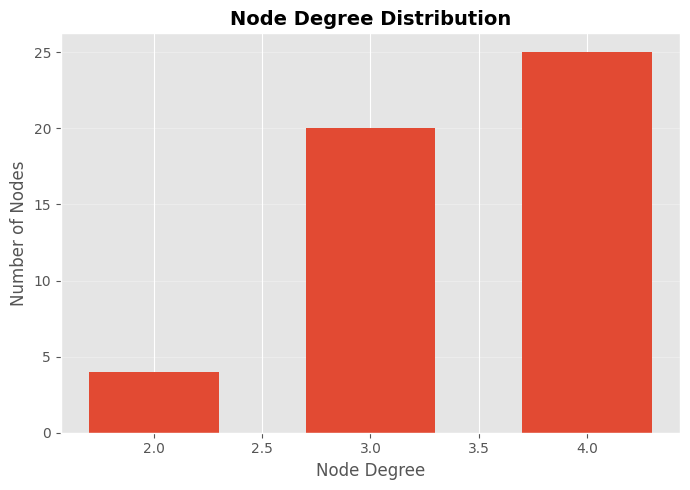

Graph Suitability Summary


,Criterion,Status
0,Fixed Image Resolution,Yes
1,Uniform Patch Grid,Yes
2,Consistent Number of Nodes,Yes
3,Spatial Neighbour Connections,Yes
4,CNN-to-Graph Conversion,Yes
5,Suitable for Graph Neural Network,Yes


Graph statistics saved successfully.


In [30]:
# ============================================================
# 19A. Graph Statistics and Suitability Analysis
# ============================================================

# ------------------------------------------------------------
# Degree calculation
# ------------------------------------------------------------

degree = np.zeros(NUM_NODES, dtype=int)

for u, v in grid_edges:
    degree[u] += 1
    degree[v] += 1


average_degree = degree.mean()
minimum_degree = degree.min()
maximum_degree = degree.max()

num_edges = len(grid_edges)

graph_density = (
    2 * num_edges
) / (
    NUM_NODES * (NUM_NODES - 1)
)


# ------------------------------------------------------------
# Graph statistics table
# ------------------------------------------------------------

graph_statistics_df = pd.DataFrame({

    "Metric":[
        "Number of Nodes",
        "Number of Undirected Edges",
        "Average Degree",
        "Minimum Degree",
        "Maximum Degree",
        "Graph Density",
    ],

    "Value":[
        NUM_NODES,
        num_edges,
        round(average_degree,2),
        minimum_degree,
        maximum_degree,
        round(graph_density,4),
    ]

})

print("Graph Statistics")

display(graph_statistics_df)


# ------------------------------------------------------------
# Degree distribution
# ------------------------------------------------------------

degree_distribution_df = (
    pd.Series(degree)
    .value_counts()
    .sort_index()
    .rename_axis("Node Degree")
    .reset_index(name="Number of Nodes")
)

print("Degree Distribution")

display(degree_distribution_df)


plt.figure(figsize=(7,5))

plt.bar(
    degree_distribution_df["Node Degree"],
    degree_distribution_df["Number of Nodes"],
    width=0.6,
)

plt.title(
    "Node Degree Distribution",
    fontsize=14,
    weight="bold",
)

plt.xlabel("Node Degree")

plt.ylabel("Number of Nodes")

plt.grid(
    axis="y",
    alpha=0.30,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"graph_degree_distribution.png",
    dpi=300,
)

plt.show()


# ------------------------------------------------------------
# Graph suitability summary
# ------------------------------------------------------------

graph_suitability_df = pd.DataFrame({

    "Criterion":[
        "Fixed Image Resolution",
        "Uniform Patch Grid",
        "Consistent Number of Nodes",
        "Spatial Neighbour Connections",
        "CNN-to-Graph Conversion",
        "Suitable for Graph Neural Network",
    ],

    "Status":[
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
    ]

})

print("Graph Suitability Summary")

display(graph_suitability_df)


# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------

graph_statistics_df.to_csv(
    TABLE_DIR/"graph_statistics.csv",
    index=False,
)

degree_distribution_df.to_csv(
    TABLE_DIR/"graph_degree_distribution.csv",
    index=False,
)

graph_suitability_df.to_csv(
    TABLE_DIR/"graph_suitability_summary.csv",
    index=False,
)


print("Graph statistics saved successfully.")

### Interpretation

The proposed graph representation contains **49 spatial nodes**, corresponding to a **7×7 CNN feature map** generated from each 28×28 BloodMNIST image.

Each node is connected to its immediate spatial neighbours, producing a regular lattice graph with consistent connectivity across all images. This fixed graph structure ensures that every sample has the same number of nodes and edges, simplifying graph construction during model training.

The relatively low graph density reflects local neighbourhood connections rather than fully connected relationships, which is desirable for Graph Convolutional Networks (GCNs) because they aggregate information from nearby regions while preserving spatial structure.

Overall, the BloodMNIST dataset is well suited for the proposed **CNN → Attention → Graph → GCN** architecture.

# 20. Patch-Level Spatial Variability Analysis

## Objective

The proposed CNN–Attention–GCN architecture converts a 28×28 BloodMNIST image into a 7×7 feature map before graph construction.

This section investigates whether different spatial regions of an image contain different levels of visual information.

For each **4×4 image patch**, we compute:

- Mean RGB intensity
- Mean grayscale intensity
- Local grayscale contrast

These statistics help determine whether local spatial information varies across the image, providing motivation for attention mechanisms and graph-based relational learning.

> **Note:** This analysis is descriptive only and does not involve CNN feature extraction.

Patch-Level Summary


,Label ID,Class,Images,Mean_Brightness,Mean_Variability,Std_Variability,Mean_Local_Contrast
0,0,Basophil,852,169.343002,55.219002,3.412,21.389999
1,1,Eosinophil,2181,174.240005,49.713001,3.679,20.951000
2,2,Erythroblast,1085,191.307999,45.167999,6.620,17.025999
3,3,Immature Granulocytes,2026,167.356003,52.668999,4.702,20.281000
4,4,Lymphocyte,849,183.345993,51.362000,3.348,19.190001
5,5,Monocyte,993,163.942993,50.032001,5.341,20.048000
6,6,Neutrophil,2330,180.783997,45.674999,3.111,20.509001
7,7,Platelet,1643,204.843994,24.879000,3.756,14.530000


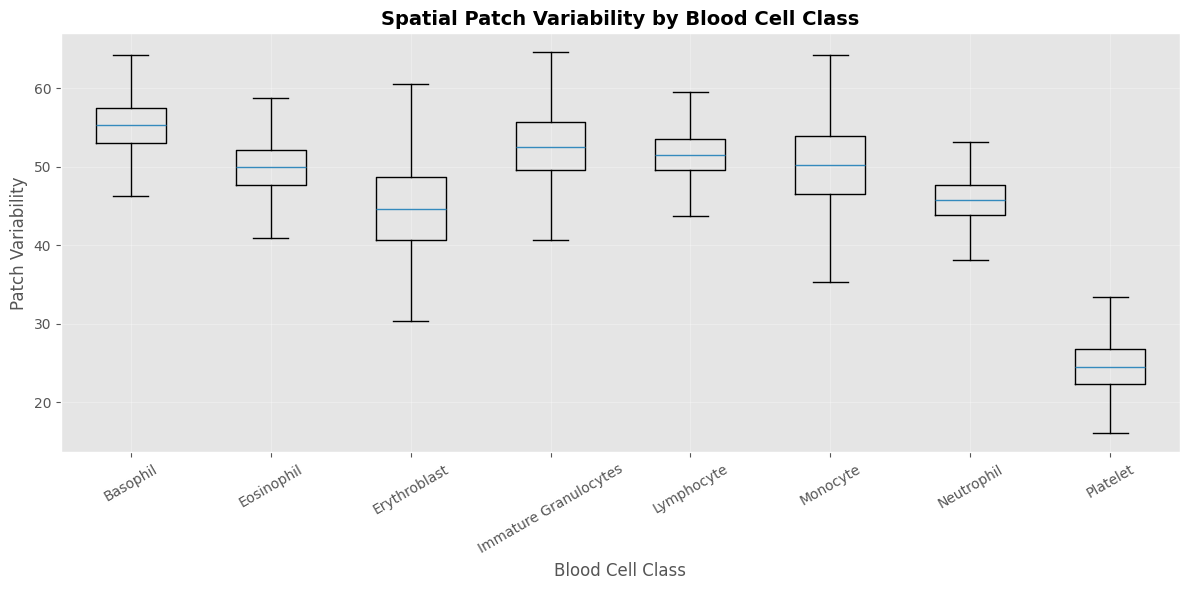

Overall Patch Statistics


,Metric,Value
0,Average Patch Brightness,179.544006
1,Average Patch Variability,46.139000
2,Average Local Contrast,19.344000


In [31]:
# ============================================================
# 20. Patch-Level Spatial Variability Analysis
# ============================================================

def extract_patch_statistics(images, patch_size=4):

    n_images, height, width, channels = images.shape

    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("Image size must be divisible by patch size.")

    grid_h = height // patch_size
    grid_w = width // patch_size

    images = images.astype(np.float32)

    patches = (
        images
        .reshape(
            n_images,
            grid_h,
            patch_size,
            grid_w,
            patch_size,
            channels,
        )
        .transpose(0,1,3,2,4,5)
    )

    patch_rgb_mean = patches.mean(axis=(3,4))

    gray = (
        0.299*patches[...,0]
        +0.587*patches[...,1]
        +0.114*patches[...,2]
    )

    patch_gray_mean = gray.mean(axis=(3,4))
    patch_gray_std = gray.std(axis=(3,4))

    return patch_rgb_mean, patch_gray_mean, patch_gray_std


(
    patch_rgb_mean,
    patch_gray_mean,
    patch_gray_std,
) = extract_patch_statistics(
    train_images,
    patch_size=PATCH_SIZE,
)


# ------------------------------------------------------------
# Per-image statistics
# ------------------------------------------------------------

patch_variability = patch_gray_mean.std(axis=(1,2))
patch_local_contrast = patch_gray_std.mean(axis=(1,2))
patch_brightness = patch_gray_mean.mean(axis=(1,2))


patch_analysis_df = pd.DataFrame({

    "Label ID":train_labels,

    "Class":[
        LABEL_MAP[int(i)]
        for i in train_labels
    ],

    "Patch Brightness":patch_brightness,

    "Spatial Patch Variability":patch_variability,

    "Local Patch Contrast":patch_local_contrast,

})


# ------------------------------------------------------------
# Class summary
# ------------------------------------------------------------

patch_summary_df = (
    patch_analysis_df
    .groupby(["Label ID","Class"])
    .agg(
        Images=("Class","count"),
        Mean_Brightness=("Patch Brightness","mean"),
        Mean_Variability=("Spatial Patch Variability","mean"),
        Std_Variability=("Spatial Patch Variability","std"),
        Mean_Local_Contrast=("Local Patch Contrast","mean"),
    )
    .reset_index()
    .round(3)
)

print("Patch-Level Summary")

display(patch_summary_df)


patch_summary_df.to_csv(
    TABLE_DIR/"patch_class_summary.csv",
    index=False,
)

patch_analysis_df.to_csv(
    TABLE_DIR/"patch_level_analysis.csv",
    index=False,
)


# ------------------------------------------------------------
# Spatial variability boxplot
# ------------------------------------------------------------

ordered_data = [

    patch_analysis_df.loc[
        patch_analysis_df["Class"]==class_name,
        "Spatial Patch Variability"
    ]

    for class_name in LABEL_MAP.values()

]


plt.figure(figsize=(12,6))

plt.boxplot(
    ordered_data,
    labels=list(LABEL_MAP.values()),
    showfliers=False,
)

plt.grid(alpha=0.30)

plt.title(
    "Spatial Patch Variability by Blood Cell Class",
    fontsize=14,
    weight="bold",
)

plt.xlabel("Blood Cell Class")

plt.ylabel("Patch Variability")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"patch_variability_boxplot.png",
    dpi=300,
)

plt.show()


# ------------------------------------------------------------
# Overall statistics
# ------------------------------------------------------------

overall_patch_statistics = pd.DataFrame({

    "Metric":[
        "Average Patch Brightness",
        "Average Patch Variability",
        "Average Local Contrast",
    ],

    "Value":[
        round(
            patch_brightness.mean(),
            3,
        ),

        round(
            patch_variability.mean(),
            3,
        ),

        round(
            patch_local_contrast.mean(),
            3,
        ),
    ]

})

print("Overall Patch Statistics")

display(overall_patch_statistics)

overall_patch_statistics.to_csv(
    TABLE_DIR/"overall_patch_statistics.csv",
    index=False,
)

## 20A. Spatial Patch Heatmap

## Objective

The previous section summarized patch statistics numerically.

This visualization shows the **average spatial intensity of each 4×4 image patch** across the entire BloodMNIST training set.

If different regions exhibit different average intensities, it suggests that local spatial information is not uniformly distributed, supporting the use of attention mechanisms and graph-based learning.

> **Higher values indicate brighter image regions on average.**

## 20A. Average 7×7 Patch Intensity Map

To further evaluate graph-readiness, the average grayscale intensity of every 4×4 spatial patch is computed across all training images.

Each cell in the heatmap corresponds to one node of the future 7×7 graph representation.

This visualization helps determine whether different spatial regions contain different levels of visual information.

A non-uniform intensity distribution indicates that different graph nodes capture different image characteristics, supporting the use of spatial attention and graph neural networks.

The numeric values are also reported to provide an exact quantitative summary.

Average Patch Intensity


,Col 1,Col 2,Col 3,Col 4,Col 5,Col 6,Col 7
Row 1,207.419998,210.179993,212.990005,213.490005,213.199997,209.860001,206.779999
Row 2,208.100006,208.070007,183.830002,167.350006,181.199997,206.429993,207.559998
Row 3,208.979996,181.509995,127.279999,108.820000,125.290001,176.779999,207.949997
Row 4,207.880005,160.289993,103.889999,90.519997,102.139999,155.029999,206.229996
Row 5,207.080002,172.279999,116.120003,98.339996,113.750000,168.100006,206.240005
Row 6,205.789993,199.929993,166.039993,147.210007,164.229996,198.589996,205.080002
Row 7,205.020004,205.320007,204.429993,201.779999,203.910004,205.080002,204.289993


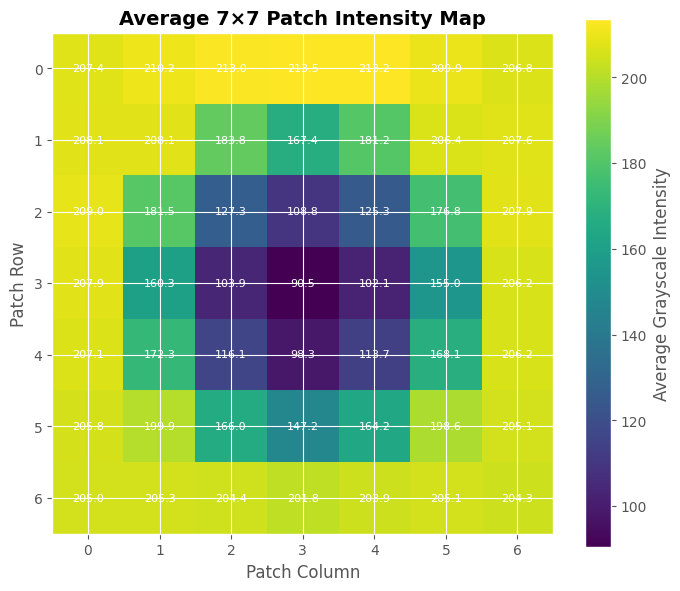

Patch heatmap saved successfully.


In [32]:
# ============================================================
# 20A. Average Spatial Patch Heatmap
# ============================================================

# Average grayscale value for every patch position
average_patch_map = patch_gray_mean.mean(axis=0)

heatmap_df = pd.DataFrame(
    average_patch_map,
    index=[f"Row {i}" for i in range(1, GRID_SIZE+1)],
    columns=[f"Col {i}" for i in range(1, GRID_SIZE+1)]
)

print("Average Patch Intensity")

display(heatmap_df.round(2))

heatmap_df.to_csv(
    TABLE_DIR/"average_patch_heatmap.csv"
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(7,6))

plt.imshow(
    average_patch_map,
    cmap="viridis",
)

plt.colorbar(label="Average Grayscale Intensity")

plt.title(
    "Average 7×7 Patch Intensity Map",
    fontsize=14,
    weight="bold",
)

plt.xlabel("Patch Column")

plt.ylabel("Patch Row")

plt.xticks(range(GRID_SIZE))

plt.yticks(range(GRID_SIZE))

# Show numeric values inside each patch
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):

        plt.text(
            j,
            i,
            f"{average_patch_map[i,j]:.1f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"average_patch_heatmap.png",
    dpi=300,
)

plt.show()

print("Patch heatmap saved successfully.")

Observation

• The outer patches have much higher average intensity than the center patches.

• The center region contains considerably darker pixels than the image borders.

• This indicates that visual information is not uniformly distributed across the image.

• Different spatial regions therefore contribute different levels of information.

EDA Conclusion

The observed spatial variation supports representing the image as a graph of spatial nodes instead of relying only on global image statistics.

This provides additional motivation for CNN feature extraction followed by Graph Neural Networks with attention mechanisms.

# 21. Automatically Generated EDA Summary and Final Conclusions

## Objective

This final section automatically summarizes the most important findings obtained throughout the exploratory data analysis (EDA).

The generated observations provide a concise overview of:

- Dataset characteristics
- Class balance
- Image quality
- Duplicate analysis
- Spatial statistics
- Prototype similarity
- Graph readiness

These findings form the justification for the proposed CNN–Attention–GCN architecture that will be implemented during Task 2.

# 21. Final EDA Summary and Key Findings

This section automatically summarizes the most important findings obtained from the exploratory data analysis (EDA).

The summary includes:

- Dataset overview
- Class imbalance analysis
- Image quality observations
- Duplicate image audit
- Graph-readiness analysis
- Final motivation for the proposed CNN + Attention + GCN architecture

These findings are automatically generated from the computed EDA results and saved for the final report.

In [33]:
# ============================================================
# 21. Final EDA Summary
# ============================================================

# -----------------------------
# Dataset Summary
# -----------------------------

total_images = (
    len(train_images)
    + len(val_images)
    + len(test_images)
)

overall_counts = (
    class_distribution_df
    .groupby("Class")["Count"]
    .sum()
)

majority_class = overall_counts.idxmax()
minority_class = overall_counts.idxmin()

majority_images = int(overall_counts.max())
minority_images = int(overall_counts.min())

imbalance_ratio = majority_images / minority_images

if imbalance_ratio < 1.5:
    dataset_status = "Balanced"
elif imbalance_ratio < 3:
    dataset_status = "Moderately Imbalanced"
else:
    dataset_status = "Highly Imbalanced"

summary_df = pd.DataFrame({

    "Metric":[

        "Total Images",
        "Training Images",
        "Validation Images",
        "Testing Images",

        "Number of Classes",

        "Image Resolution",

        "Image Channels",

        "Pixel Range",

        "Majority Class",

        "Minority Class",

        "Majority Images",

        "Minority Images",

        "Class Imbalance Ratio",

        "Dataset Status",

        "Graph Grid",

        "Graph Nodes"

    ],

    "Value":[

        total_images,

        len(train_images),

        len(val_images),

        len(test_images),

        len(LABEL_MAP),

        f"{train_images.shape[1]}×{train_images.shape[2]}",

        train_images.shape[3],

        f"{train_images.min()} - {train_images.max()}",

        majority_class,

        minority_class,

        majority_images,

        minority_images,

        f"{imbalance_ratio:.2f}:1",

        dataset_status,

        f"{GRID_SIZE}×{GRID_SIZE}",

        GRID_SIZE*GRID_SIZE

    ]

})

print("="*70)
print("FINAL EDA SUMMARY")
print("="*70)

display(summary_df)

summary_df.to_csv(
    TABLE_DIR/"final_eda_summary.csv",
    index=False
)

summary_path = OUTPUT_DIR/"final_eda_summary.txt"

with open(summary_path,"w",encoding="utf-8") as f:

    f.write("FINAL EDA SUMMARY\n")
    f.write("="*70+"\n\n")

    for _, row in summary_df.iterrows():

        f.write(
            f"{row['Metric']}: {row['Value']}\n"
        )

print("\nSummary saved successfully.")

print(summary_path)

FINAL EDA SUMMARY


,Metric,Value
0,Total Images,17092
1,Training Images,11959
2,Validation Images,1712
3,Testing Images,3421
4,Number of Classes,8
5,Image Resolution,28×28
6,Image Channels,3
7,Pixel Range,0 - 255
8,Majority Class,Neutrophil
9,Minority Class,Lymphocyte



Summary saved successfully.
task1_eda_outputs/final_eda_summary.txt
